# 异构无人机多点多架次运输调度

定位：问题二的完整求解链条。节点与机型数据、航段几何、三阶段时间和能耗、返航安全余量沿用问题一的口径；本 Notebook 自带实现，不依赖问题一的运行状态。数据在本机的 D 题目录读取，结果图写入本机结果目录。

## 1 问题台账（读题结果）

| 项目 | 内容 |
|---|---|
| 研究对象 | 8 架实体运输无人机（A×4、B×2、C×2）与共享电池（A 型 6 组、B 型 4 组、C 型 4 组），在 O01 与 15 个服务区之间执行多点、多架次运输调度 |
| 决策变量 | 货箱组批、每架次服务区访问顺序、机型与具体无人机、电池、架次开始时刻 |
| 硬约束 | 货箱不可拆、每箱恰好配送一次；架次总质量不超过机型载荷上限、总体积不超过机型可用装载体积；架次能耗不超过含返航安全余量的可用能量；同一无人机任务不重叠；同一电池完成任务并充至 100% 后方可再次使用；医疗物资不晚于期望送达时间，首批保障箱不晚于首批截止时间 |
| 软目标 | 其他货箱的期望送达时间用于衡量及时性，迟到越少越好 |
| 任务 1 | 综合优化配送及时性、全部任务完成时间（最后一架返回 O01 的时刻）、运输能耗和架次数，并说明权衡关系 |
| 任务 2 | 给出运输路线、架次安排、逐箱送达时刻、无人机与电池资源使用情况，并检验资源可行性 |
| 本问不考 | 通信保障（问题三）、任务分区（问题四） |
| 论文必须呈现 | 航线表与航线图、调度甘特图、逐箱送达时刻表、电池 SOC/充电时序、四指标权衡分析和可行性检验结论 |

## 2 与问题一的数据继承关系

- 继承节点坐标与海拔、30 m DEM、机型参数、逐箱清单；航段几何采用 WGS84 椭球局部距离与 Amanatides–Woo 像元遍历；继承等效航程能耗模型、三阶段时间模型和返航安全余量口径。
- 扩展对象：由 O01—服务区的单航段扩展到任意节点对，形成 16×16 航段矩阵；由逐架次求和扩展到包含实体无人机、共享电池和两阶段充电的资源时间轴。
- 问题一的最大安全载荷仍是有用上界；多点架次增加中途爬升与航程，实际可载量可能更少。本问按逐航段能耗精确判定。

## 3 技术路线

航段矩阵（16×16 距离与巡航海拔）→ 逐航段时间和能耗系数 → 货箱清单（质量、体积、时限、优先系数）→ 架次评估器（载荷递减、逐箱送达偏移、能耗、时长）→ 自适应大邻域搜索 ALNS（破坏与修复组批和访问顺序、模拟退火接受、算子权重自适应）。

每次候选评估均调用列表调度解码器：按最迟开始时刻排序，依次选择最早可用的同型无人机和电池，计算开始/结束时刻、SOC 与充电完成时刻。最后对调度顺序做交换局部搜索，运行推荐权重及四种权衡情景，独立检验可行性，并生成图表。


## 4 题目规则的数学化（多点架次、资源与时限）

**（1）多点架次的航段链。** 架次 $p$ 由机型 $g$ 执行，路径为
$$O_{01}\to S_{a_1}\to S_{a_2}\to\cdots\to S_{a_k}\to O_{01}.$$
相邻节点 $(i,j)$ 间取水平直线。巡航海拔为
$$H_{ij}=\max\{\mathrm{DEM}(c):c\text{ 为航段所经像元}\}+50,$$
两端作业高度为 $z_O^{op}=z_O$、$z_S^{op}=z_S+30$，并记
$$h_{ij}^{+}=(H_{ij}-z_i^{op})_+,\qquad h_{ij}^{-}=(H_{ij}-z_j^{op})_+,$$
$$t_{gij}=\frac{h_{ij}^{+}}{v_g^{up}}+\frac{d_{ij}}{v_g^c}+\frac{h_{ij}^{-}}{v_g^{dn}}.$$
连续访问多个服务区时，每次投送后都从 30 m 作业高度重新爬升；每个航段独立经历“爬升—巡航—下降”，中途不在巡航高度直飞。

**（2）载荷递减与航段能耗。** 令 $q_{p,0}$ 为起飞载荷，在服务区 $S_{a_r}$ 卸下质量 $m_{a_r}$ 后，
$$q_{p,r}=q_{p,r-1}-m_{a_r}.$$
沿用问题一的等效航程能耗模型：
$$L_g(q)=L_g^0-(L_g^0-L_g^F)(q/Q_g)^{3/2},$$
$$E_{gij}(q)=\frac{d_{ij}E_g^{use}}{L_g(q)}+
\frac{(m_g^0+q)g_0h_{ij}^{+}}{\eta_g^{up}\,3.6\times10^6},\qquad
E_p=\sum_r E_{g,i_r i_{r+1}}(q_{p,r})\le(1-\rho_g)E_g^{use}.$$

**（3）架次时间轴与逐箱送达时刻。** 架次在 $t_p^{st}$ 开始，先完成固定准备和逐箱装载，再起飞。到达服务区后先进行基础交接，再逐箱交接；第 $b$ 箱的送达时刻取交接完成时刻。同一站内按硬时限早者优先、应急优先系数高者优先。架次结束时刻 $t_p^{en}$ 为返回 O01 的时刻，架次时长为 $t_p=t_p^{en}-t_p^{st}$。

**（4）电池 SOC 与两阶段充电。** 任务结束 SOC 为
$$s_p=1-E_p/E_g^{use}\ge\rho_g.$$
电池再次投入前需充至 100%。若 0%→90% 快充占完全充电时间的 65%，90%→100% 慢充占 35%，从 SOC $s$ 充满所需时间为
$$t_g^{chg}(s)=
\begin{cases}
T_g^{full}\left[0.65(0.9-s)/0.9+0.35\right],&s<0.9,\\
T_g^{full}\,0.35(1-s)/0.1,&s\ge0.9.
\end{cases}$$
同型电池可在同型无人机间调度，不同机型电池不可混用。

**（5）实体无人机与周转。** 同一无人机的相邻架次满足前一架次返回后才能开始下一架次。换电等地面作业计入下一架次固定准备时间，取 $t_g^{prep}=300$ s。初始时全部无人机位于 O01，所有电池 SOC 均为 100%。

**（6）及时性指标。** 记 $t_b$ 为货箱送达时刻、$t_b^{exp}$ 为期望送达时刻、$w_b$ 为应急优先系数。医疗物资满足 $t_b\le t_b^{exp}$，首批保障箱满足 $t_b\le t_b^{first}$。定义优先加权平均迟到与平均送达时刻
$$\bar L=\frac{\sum_b w_b\max(0,t_b-t_b^{exp})}{\sum_b w_b},\qquad
\bar D=\frac{\sum_b w_b t_b}{\sum_b w_b}.$$
$\bar L$ 是主要及时性指标，$\bar D$ 是次指标，用于在“都不迟到”时区分送达早晚。

**（7）四个优化指标。** 及时性 $f_T=(\bar L+0.1\bar D)/3600$，完成时间 $f_M=\max_p t_p^{en}/3600$，能耗 $f_E=\sum_p E_p$，架次数 $f_N=|P|$。标量化目标为
$$F=w_T f_T+w_M f_M+w_E\frac{f_E}{50}+w_N\frac{f_N}{20}
+100\sum_{b\in B^{hard}}\frac{(t_b-t_b^{hard})_+}{3600}
+5\sum_{b\in B^{hard}}\mathbf 1(t_b>t_b^{hard}).$$
硬时限罚函数按每迟到 1 h 罚 100、每箱违约罚 5 设置。权重 $(w_T,w_M,w_E,w_N)$ 在情景分析中扫描；推荐权重取 $(3,1.5,1,0.5)$ -- 救援场景下及时性优先、其次是尽早完成全部任务、再考虑能耗与架次。


## 5 运行环境、字体与图表主题

依赖 NumPy、pandas、SciPy、Matplotlib 与 openpyxl。中文优先使用宋体，英文和数字优先使用 Times New Roman；未安装时自动使用本机可用字体并提示。图片采用 300 dpi 输出，统一设置颜色、字号、线宽与图例样式。


In [1]:
import math, json, time, itertools, bisect, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import font_manager
from matplotlib.colors import LightSource, LinearSegmentedColormap, ListedColormap, Normalize, BoundaryNorm
from matplotlib.patches import Rectangle, Polygon as MplPolygon, FancyBboxPatch
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection, PolyCollection
import matplotlib.patheffects as pe

warnings.filterwarnings('ignore')
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40); pd.set_option('display.max_rows', 120)
T_START = time.time()

# ---------- 本机目录：无论从项目根目录还是 002-Code 启动内核均可运行 ----------
NOTEBOOK_DIR = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / '26-Modeling/002-Code/Q2.ipynb').exists()), None)
PROJECT = NOTEBOOK_DIR if NOTEBOOK_DIR is not None else Path.cwd().parents[1]
BASE_DIR = PROJECT / '26-Modeling/001-Issue/D题'
OUT_DIR = PROJECT / '26-Modeling/003-Picture/问题二'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def find_file(name):
    """先在当前目录找，找不到再递归子目录找。"""
    p = BASE_DIR / name
    if p.exists():
        return p
    hits = list(BASE_DIR.rglob(name))
    if hits:
        return hits[0]
    raise FileNotFoundError(f'未找到文件 {name}：请检查 001-Issue/D题 下的原始附件')


# ────────── 字体 ──────────
def setup_fonts():
    cands = ['C:/Windows/Fonts/simsun.ttc', 'C:/Windows/Fonts/times.ttf', 'C:/Windows/Fonts/timesbd.ttf',
             '/System/Library/Fonts/Supplemental/Songti.ttc', '/System/Library/Fonts/Supplemental/Times New Roman.ttf',
             '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf']
    for c in cands:
        if Path(c).exists():
            try:
                font_manager.fontManager.addfont(c)
            except Exception:
                pass
    names = {f.name for f in font_manager.fontManager.ttflist}
    cn = next((n for n in ['SimSun', '宋体', 'Songti SC', 'Noto Serif CJK SC', 'Noto Serif CJK JP', 'Source Han Serif SC',
                           'Noto Sans CJK SC', 'Noto Sans CJK JP', 'Microsoft YaHei', 'SimHei', 'WenQuanYi Micro Hei'] if n in names), None)
    en = next((n for n in ['Times New Roman', 'Liberation Serif', 'DejaVu Serif', 'STIXGeneral'] if n in names), 'serif')
    fam = [en] + ([cn] if cn else [])
    plt.rcParams['font.family'] = fam
    plt.rcParams['font.serif'] = fam
    plt.rcParams['axes.unicode_minus'] = False
    plt.rcParams['mathtext.fontset'] = 'stix'
    return en, cn


EN_FONT, CN_FONT = setup_fonts()
print(f'英文/数字字体: {EN_FONT}    中文字体: {CN_FONT}' +
      ('' if CN_FONT == 'SimSun' else '（提示：未检测到宋体，已使用替代中文字体）'))


# ────────── 统一视觉主题 ──────────
PAL = dict(indigo='#1F3A5F', teal='#2A9D8F', coral='#E76F51', gold='#E9C46A', plum='#6D597A',
           sky='#8AB6D6', grey='#8D99AE', ink='#2B2D42', mist='#E4E6EB', sand='#B8AFA2')
TYPE_COLOR = {'A': '#2A9D8F', 'B': '#1F3A5F', 'C': '#E76F51'}  # 机型
MAT_COLOR = {'医疗物资': '#C8553D', '饮用水': '#3A7CA5', '应急食品': '#E9B44C', '生活卫生用品': '#7B6D8D'}  # 物资
MAT_ABBR = {'医疗物资': 'MED', '饮用水': 'WAT', '应急食品': 'FOD', '生活卫生用品': 'HYG'}
CMAP_SEQ = LinearSegmentedColormap.from_list('seq', ['#2A9D8F', '#1F3A5F', '#E76F51'])  # 青绿→靛蓝→珊瑚

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300, 'savefig.bbox': 'tight', 'savefig.facecolor': 'white',
    'axes.facecolor': 'white', 'axes.edgecolor': '#A4A6E9', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#E4E6EB', 'grid.linewidth': 0.6,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 8.5, 'legend.frameon': False,
    'xtick.color': '#A4A6E9', 'ytick.color': '#A4A6E9', 'axes.labelcolor': '#2B2D42', 'text.color': '#2B2D42',
    'lines.linewidth': 1.6, 'patch.linewidth': 0.8,
})

HALO = [pe.withStroke(linewidth=2.5, foreground='white')]  # 文字白色描边，避免压在地形上看不清


def savefig(fig, name):
    fig.savefig(OUT_DIR / f'{name}.png')
    print(f'🖼️ 已保存 {OUT_DIR.name}/{name}.png')

英文/数字字体: Times New Roman    中文字体: Songti SC（提示：未检测到宋体，已使用替代中文字体）


## 6 数据

读取方式与问题一相同，块状 Excel 由 read_block 解析。本问另外使用逐架无人机清单与共享电池库存。读取后汇总实体资源和硬时限箱，并计算每箱的硬时限：首批保障箱取首批截止时间，医疗物资取期望送达时间，其余箱无硬时限。


In [2]:
def read_block(df, title):
    """从块状 Excel 中读取名为 title 的数据块（标题行 → 表头行 → 数据行 → 空行）。"""
    col0 = df[0].astype(str).str.strip()
    idx = int(col0.index[col0 == title][0])
    header = [str(h).strip() for h in df.iloc[idx + 1].tolist()]
    rows = []
    for k in range(idx + 2, len(df)):
        r = df.iloc[k]
        if r.isna().all():
            break
        rows.append(r.tolist())
    out = pd.DataFrame(rows, columns=header).dropna(axis=1, how='all')
    return out.loc[:, [c for c in out.columns if c != 'nan']].reset_index(drop=True)

In [3]:
raw_node = pd.read_excel(find_file('调度中心与服务区.xlsx'), header=None)
depot = read_block(raw_node, '调度中心').rename(columns={
    '调度中心编号':'id', '调度中心名称':'name', '经度（°）':'lon', '纬度（°）':'lat', '海拔（m）':'elev'})
areas = read_block(raw_node, '服务区').rename(columns={
    '服务区编号':'id', '服务区名称':'name', '经度（°）':'lon', '纬度（°）':'lat',
    '海拔（m）':'elev', '本次需保障人口（人）':'pop'})
for c in ('lon','lat','elev'):
    depot[c] = pd.to_numeric(depot[c]); areas[c] = pd.to_numeric(areas[c])
areas['pop'] = pd.to_numeric(areas['pop']).astype(int)
AREA_IDS = areas['id'].tolist()
LON_O, LAT_O, Z_O = depot.loc[0, ['lon','lat','elev']].astype(float)

raw_uav = pd.read_excel(find_file('运输无人机数据.xlsx'), header=None)
uav_cols = {
    '机型编号':'g', '机型名称':'name', '含电池空载总质量（kg）':'m0',
    '最大载货质量（kg）':'Q', '可用装载体积（m³）':'V', '计划巡航速度（m/s）':'v_c',
    '空载标准航程（m）':'L0', '满载标准航程（m）':'LF', '电池可用能量（kWh）':'E_use',
    '返航电量下限（%）':'rho_pct', '工位固定准备时间（s）':'t_prep',
    '每箱装载时间（s）':'t_load', '接收点基础交接时间（s）':'t_hand',
    '每箱增加交接时间（s）':'t_box', '最大爬升速度（m/s）':'v_up',
    '最大下降速度（m/s）':'v_dn', '爬升能耗效率':'eta_up', '下降能耗效率':'eta_dn'}
uav = read_block(raw_uav, '三类机型参数').rename(columns=uav_cols)
for c in uav.columns.difference(['g','name']): uav[c] = pd.to_numeric(uav[c])
uav['rho'] = uav['rho_pct'] / 100
uav = uav.set_index('g')
TYPES = uav.index.tolist()
fleet = read_block(raw_uav, '逐架无人机清单')
battery = read_block(raw_uav, '共享电池库存')

demand_path = find_file('物资需求与配送时限.xlsx')
demand = pd.read_excel(demand_path, sheet_name='数据')
boxes = pd.read_excel(demand_path, sheet_name='逐箱货箱清单').rename(columns={
    '货箱编号':'box', '服务区编号':'area', '物资类型':'mat', '单箱质量（kg）':'mass',
    '单箱体积（m³）':'vol', '是否首批保障':'first', '首批截止时间（s）':'deadline',
    '期望送达时间（s）':'expected', '应急优先系数':'priority'})
boxes['first'] = boxes['first'].eq('是')
boxes['mass'] = pd.to_numeric(boxes['mass']); boxes['vol'] = pd.to_numeric(boxes['vol'])
MAT_ORDER = ['医疗物资','饮用水','应急食品','生活卫生用品']

def load_dem():
    m = sio.loadmat(find_file('镇龙乡及周边30米DEM.mat'))
    arr = m['dem'].astype(np.float32)
    tr = m['transform'].ravel()
    nodata = float(m['nodata'].ravel()[0]); arr[arr == nodata] = np.nan
    return arr, dict(dx=float(tr[0]), dy=float(-tr[4]), lon0=float(tr[2]), lat0=float(tr[5]))

DEM, GEO = load_dem()
NROW, NCOL = DEM.shape
roads=pd.read_csv(find_file('镇龙乡及周边道路.csv'),encoding='utf-8-sig')
water=pd.read_csv(find_file('镇龙乡及周边水体.csv'),encoding='utf-8-sig')
rivers=pd.read_csv(find_file('镇龙乡及周边水系.csv'),encoding='utf-8-sig')
places=pd.read_csv(find_file('镇龙乡及周边村镇点位.csv'),encoding='utf-8-sig')
LON_C = GEO['lon0'] + (np.arange(NCOL) + .5) * GEO['dx']
LAT_C = GEO['lat0'] - (np.arange(NROW) + .5) * GEO['dy']
def to_pix(lon, lat):
    return (lon-GEO['lon0'])/GEO['dx'], (GEO['lat0']-lat)/GEO['dy']
def dem_at(lon, lat):
    x,y = to_pix(lon,lat)
    return float(DEM[int(math.floor(y)),int(math.floor(x))])

assert len(depot)==1 and len(areas)==15 and len(boxes)==80
assert boxes.box.is_unique and set(boxes.area)==set(AREA_IDS)
assert TYPES==['A','B','C'] and DEM.shape==(1309,1486)
node_check = areas[['id','name','lon','lat','elev','pop']].copy()
node_check['DEM_m'] = [dem_at(r.lon,r.lat) for r in areas.itertuples()]
node_check['差值_m'] = node_check.elev-node_check.DEM_m
print(f'节点 1+{len(areas)}；逐箱 {len(boxes)}；DEM {NROW}×{NCOL}；机型 {TYPES}')
print(f'O01 附件海拔 {Z_O:.1f} m，DEM {dem_at(LON_O,LAT_O):.1f} m')
ledger=pd.DataFrame([
    ('节点','调度中心与服务区.xlsx',len(areas)+len(depot),'经纬度、海拔、人口'),
    ('机型','运输无人机数据.xlsx',len(uav),'质量、航程、能量、速度、作业时间'),
    ('货箱','物资需求与配送时限.xlsx',len(boxes),'质量、体积、首批标记'),
    ('DEM','镇龙乡及周边30米DEM.mat',DEM.size,'30 m 地形高程'),
    ('道路/水系/水体/村镇','地理空间 CSV',len(roads)+len(rivers)+len(water)+len(places),'背景地图图层')],
    columns=['对象','文件','记录数','本问用途'])
display(ledger)
display(node_check.round(2), uav[['Q','V','L0','LF','E_use','rho']])

节点 1+15；逐箱 80；DEM 1309×1486；机型 ['A', 'B', 'C']
O01 附件海拔 127.7 m，DEM 128.7 m


,对象,文件,记录数,本问用途
0,节点,调度中心与服务区.xlsx,16,经纬度、海拔、人口
1,机型,运输无人机数据.xlsx,3,质量、航程、能量、速度、作业时间
2,货箱,物资需求与配送时限.xlsx,80,质量、体积、首批标记
3,DEM,镇龙乡及周边30米DEM.mat,1945174,30 m 地形高程
4,道路/水系/水体/村镇,地理空间 CSV,29980,背景地图图层


,id,name,lon,lat,elev,pop,DEM_m,差值_m
0,S001,平旺、那龙、镇龙乡,109.24,23.03,154.0,2100,153.96,0.04
1,S002,上良,109.26,23.07,189.5,330,188.79,0.71
2,S003,六造、那旭、都长,109.17,23.04,308.5,275,308.51,-0.01
3,S004,大站,109.24,23.08,198.3,188,195.12,3.18
4,S005,上良、古律、那麓,109.23,23.06,165.0,126,169.04,-4.04
5,S006,六昌、木路,109.20,23.01,284.8,121,275.13,9.67
6,S007,佛子、那桑、银坑,109.19,23.03,318.5,76,314.22,4.28
7,S008,古麻、大站,109.21,23.08,240.9,55,248.29,-7.39
8,S009,那龙,109.25,23.06,200.0,45,189.44,10.56
9,S010,镇龙乡,109.28,23.02,321.6,31,321.58,0.02


,Q,V,L0,LF,E_use,rho
g,,,,,,
A,25,0.060,25000,20000,4.5,0.2
B,30,0.073,28000,16000,4.0,0.2
C,80,0.250,26000,12000,8.0,0.2


In [4]:
# 实体资源来自附件，而不是按机型假设无限架无人机或电池。
UAV_TYPE=dict(zip(fleet['无人机编号'], fleet['机型编号']))
UAV_LIST=tuple(fleet['无人机编号'])
BATT={r['机型编号']:(int(r['共享电池组总数（组）']), float(r['等效完全充电时间（s）'])) for _,r in battery.iterrows()}
BATTS={g:tuple(f'{g}-B{k+1}' for k in range(BATT[g][0])) for g in TYPES}
NODE_IDS=('O01',*AREA_IDS); AREA_IDX={a:i+1 for i,a in enumerate(AREA_IDS)}
NODES=pd.concat([depot[['id','lon','lat','elev']], areas[['id','lon','lat','elev']]],ignore_index=True)
LONS=NODES.lon.to_numpy(float); LATS=NODES.lat.to_numpy(float); ELEV=NODES.elev.to_numpy(float)
box_data=boxes.reset_index(drop=True).copy(); BOX_IDS=tuple(box_data.box); BOX_IDX={b:i for i,b in enumerate(BOX_IDS)}
b_area=np.array([AREA_IDX[a] for a in box_data.area],int)
b_mass=box_data.mass.to_numpy(float); b_vol=box_data.vol.to_numpy(float)
b_mat=box_data.mat.to_numpy(str); b_exp=box_data.expected.to_numpy(float)
b_w=box_data.priority.to_numpy(float)
# MED 一律按期望送达硬约束；首批其他物资按首批截止时间。
b_hard=np.where(b_mat=='医疗物资',b_exp,np.where(box_data['first'].to_numpy(),box_data.deadline.to_numpy(float),np.inf))
b_kind=np.where(b_mat=='医疗物资','医疗硬时限',np.where(box_data['first'].to_numpy(),'首批硬时限','软时限'))
assert len(UAV_LIST)==8 and sum(v[0] for v in BATT.values())==14 and len(BOX_IDS)==80
print('无人机:',UAV_TYPE,'\n共享电池:',BATT,'\n硬时限箱:',int(np.isfinite(b_hard).sum()))
display(box_data.groupby(['area','mat']).agg(箱数=('box','size'),质量kg=('mass','sum')).head(20))

boxes['hard_time']=b_hard
boxes['hard_kind']=b_kind
boxes['has_hard']=np.isfinite(b_hard)
def shade(color, amount):
    rgb=np.array(mpl.colors.to_rgb(color))
    return tuple(rgb+(1-rgb)*amount)
UAV_COLOR={}
for g in TYPES:
    us=[u for u in UAV_LIST if UAV_TYPE[u]==g]
    for k,u in enumerate(us):
        UAV_COLOR[u]=shade(TYPE_COLOR[g],.45*k/max(1,len(us)-1))
print('实体无人机：',[(u,UAV_TYPE[u]) for u in UAV_LIST])
print('共享电池：',BATT)
hard_summary=boxes[boxes.has_hard].groupby(['hard_kind','deadline'],dropna=False).agg(
    箱数=('box','size'),服务区=('area',lambda x:', '.join(sorted(set(x)))))
print('硬时限货箱：'); display(hard_summary)
print('软时限（期望送达）分布：')
display(boxes.groupby('expected').agg(箱数=('box','size'),总质量kg=('mass','sum')).T)


无人机: {'U01': 'A', 'U02': 'A', 'U03': 'A', 'U04': 'A', 'U05': 'B', 'U06': 'B', 'U07': 'C', 'U08': 'C'} 
共享电池: {'A': (6, 1800.0), 'B': (4, 2400.0), 'C': (4, 3000.0)} 
硬时限箱: 31


箱数  质量kg
area mat             
S001 医疗物资     2     6
     应急食品     3    24
     生活卫生用品   2    12
     饮用水      8   112
S002 医疗物资     1     3
     应急食品     2    16
     生活卫生用品   1     6
     饮用水      4    56
S003 医疗物资     1     3
     应急食品     2    16
     生活卫生用品   1     6
     饮用水      4    56
S004 医疗物资     1     3
     应急食品     1     8
     生活卫生用品   1     6
     饮用水      3    42
S005 医疗物资     1     3
     应急食品     1     8
     生活卫生用品   1     6
     饮用水      3    42

实体无人机： [('U01', 'A'), ('U02', 'A'), ('U03', 'A'), ('U04', 'A'), ('U05', 'B'), ('U06', 'B'), ('U07', 'C'), ('U08', 'C')]
共享电池： {'A': (6, 1800.0), 'B': (4, 2400.0), 'C': (4, 3000.0)}
硬时限货箱：


箱数                                             服务区
hard_kind deadline                                                    
医疗硬时限     3600.0     8  S001, S002, S006, S007, S010, S012, S013, S014
          7200.0     4                          S003, S004, S008, S015
          10800.0    3                                S005, S009, S011
          NaN        1                                            S001
首批硬时限     3600.0     8  S001, S002, S006, S007, S010, S012, S013, S014
          7200.0     3                                S003, S004, S008
          10800.0    4                          S005, S009, S011, S015

软时限（期望送达）分布：


expected,3600,7200,10800,14400,18000
箱数,28,26,18,7,1
总质量kg,315,232,155,50,6


## 7 航段矩阵：任意两节点的距离、巡航海拔与逐机型时间—能耗系数

多点架次需要 O01 与 15 个服务区共 16 个节点两两之间的航段。水平距离采用 WGS84 椭球局部公式；巡航海拔由 Amanatides–Woo 网格遍历逐像元取最高值后加 50 m。为减少搜索期间的重复计算，预先构造每个机型、每个有向航段的时间、能耗系数和爬升高度：
$$E_{gij}(q)=\frac{A_{gij}}{L_g(q)}+B_{gij}(m_g^0+q),\quad
A_{gij}=d_{ij}E_g^{use},\quad B_{gij}=\frac{g_0 h_{ij}^{+}}{\eta_g^{up}3.6\times10^6}.$$
图 1 在同一矩阵上用上三角显示距离、下三角显示巡航海拔，对角线显示节点作业高度。服务区之间的直飞航段往往明显短于经 O01 中转，是多点架次节省架次与能耗的几何来源。


In [5]:
A_WGS, F_WGS = 6378137.0, 1/298.257223563
E2_WGS = 2*F_WGS - F_WGS**2
def dist_m(lon0,lat0,lon1,lat1):
    phi = math.radians((lat0+lat1)/2); s2 = math.sin(phi)**2
    M = A_WGS*(1-E2_WGS)/(1-E2_WGS*s2)**1.5
    N = A_WGS/math.sqrt(1-E2_WGS*s2)
    return math.hypot(math.radians(lat1-lat0)*M, math.radians(lon1-lon0)*N*math.cos(phi))

def traverse_cells(x0,y0,x1,y1):
    ix,iy = math.floor(x0),math.floor(y0)
    dx,dy=x1-x0,y1-y0
    sx,sy=(1 if dx>0 else -1),(1 if dy>0 else -1)
    tdx=abs(1/dx) if dx else math.inf; tdy=abs(1/dy) if dy else math.inf
    tmx=((ix+1-x0)/dx if dx>0 else (ix-x0)/dx) if dx else math.inf
    tmy=((iy+1-y0)/dy if dy>0 else (iy-y0)/dy) if dy else math.inf
    cells=[(iy,ix)]
    while len(cells)<100000:
        if tmx<tmy:
            if tmx>1: break
            ix+=sx; tmx+=tdx
        else:
            if tmy>1: break
            iy+=sy; tmy+=tdy
        cells.append((iy,ix))
    return cells


CLEARANCE,H_SERVICE=50.0,30.0
GEOM={}; DIST=np.zeros((16,16)); HCRUISE=np.zeros((16,16)); PIXELS=np.zeros((16,16),int)
for i in range(16):
    for j in range(16):
        if i==j: continue
        x0,y0=to_pix(LONS[i],LATS[i]); x1,y1=to_pix(LONS[j],LATS[j])
        cells=traverse_cells(x0,y0,x1,y1)
        zmax=float(np.nanmax([DEM[r,c] for r,c in cells])); H=zmax+CLEARANCE
        zi=ELEV[i]+(H_SERVICE if i else 0); zj=ELEV[j]+(H_SERVICE if j else 0)
        d=dist_m(LONS[i],LATS[i],LONS[j],LATS[j])
        GEOM[i,j]=(d,H,max(0.,H-zi),max(0.,H-zj),len(cells))
        DIST[i,j]=d; HCRUISE[i,j]=H; PIXELS[i,j]=len(cells)
assert len(GEOM)==240 and np.allclose(DIST,DIST.T,atol=1e-4)
LEG_T={}; LEG_A={}; LEG_B={}; HUP={}; HDN={}
for g in TYPES:
    p=uav.loc[g]
    T=np.zeros((16,16)); A=np.zeros((16,16)); B=np.zeros((16,16))
    HU=np.zeros((16,16)); HD=np.zeros((16,16))
    for i,j in GEOM:
        d,_,hup,hdn,_=GEOM[i,j]
        T[i,j]=hup/p.v_up+d/p.v_c+hdn/p.v_dn
        A[i,j]=d*p.E_use
        B[i,j]=9.81*hup/(p.eta_up*3.6e6)
        HU[i,j]=hup; HD[i,j]=hdn
    LEG_T[g]=T; LEG_A[g]=A; LEG_B[g]=B; HUP[g]=HU; HDN[g]=HD
pairs=sorted((DIST[i,j]/1000,NODE_IDS[i],NODE_IDS[j])
             for i in range(1,16) for j in range(i+1,16))
print('无向节点对:',len(pairs),'；有向航段:',len(GEOM),
      '；距离范围 km:',round(DIST[DIST>0].min()/1000,2),round(DIST.max()/1000,2))
print('服务区之间最近约 5 对：'+'；'.join(f'{a}—{b} {d:.2f} km' for d,a,b in pairs[:5]))
display(pd.DataFrame(DIST/1000,index=NODE_IDS,columns=NODE_IDS).round(2))

无向节点对: 105 ；有向航段: 240 ；距离范围 km: 1.38 12.39
服务区之间最近约 5 对：S010—S013 1.38 km；S002—S009 1.72 km；S010—S014 1.75 km；S007—S015 2.22 km；S002—S004 2.25 km


,O01,S001,S002,S003,S004,S005,S006,S007,S008,S009,S010,S011,S012,S013,S014,S015
O01,0.00,3.05,7.41,7.26,7.71,5.28,3.19,4.53,8.08,5.71,4.78,2.81,7.39,4.85,5.42,6.01
S001,3.05,0.00,4.36,7.66,4.93,2.93,5.30,5.19,5.97,2.65,3.71,2.35,4.70,2.90,5.20,5.50
S002,7.41,4.36,0.00,9.78,2.25,3.48,9.18,8.12,4.80,1.72,5.92,5.78,3.07,4.54,7.65,7.16
S003,7.26,7.66,9.78,0.00,8.23,6.34,4.80,2.73,6.25,8.90,11.22,5.36,11.82,10.56,12.39,2.62
S004,7.71,4.93,2.25,8.23,0.00,2.61,8.71,7.10,2.61,2.99,7.55,5.40,5.29,6.20,9.29,5.65
S005,5.28,2.93,3.48,6.34,2.61,0.00,6.11,4.69,3.04,2.65,6.36,2.80,5.62,5.21,8.00,3.75
S006,3.19,5.30,9.18,4.80,8.71,6.11,0.00,2.51,8.06,7.67,7.92,3.41,9.99,7.78,8.60,4.68
S007,4.53,5.19,8.12,2.73,7.10,4.69,2.51,0.00,5.91,6.91,8.60,2.83,9.66,8.05,9.68,2.22
S008,8.08,5.97,4.80,6.25,2.61,3.04,8.06,5.91,0.00,5.02,9.29,5.33,7.73,8.05,10.97,3.93
S009,5.71,2.65,1.72,8.90,2.99,2.65,7.67,6.91,5.02,0.00,4.56,4.33,2.97,3.21,6.32,6.36


🖼️ 已保存 q2-main-8000-polish-4000-output/图01_航段几何矩阵.png


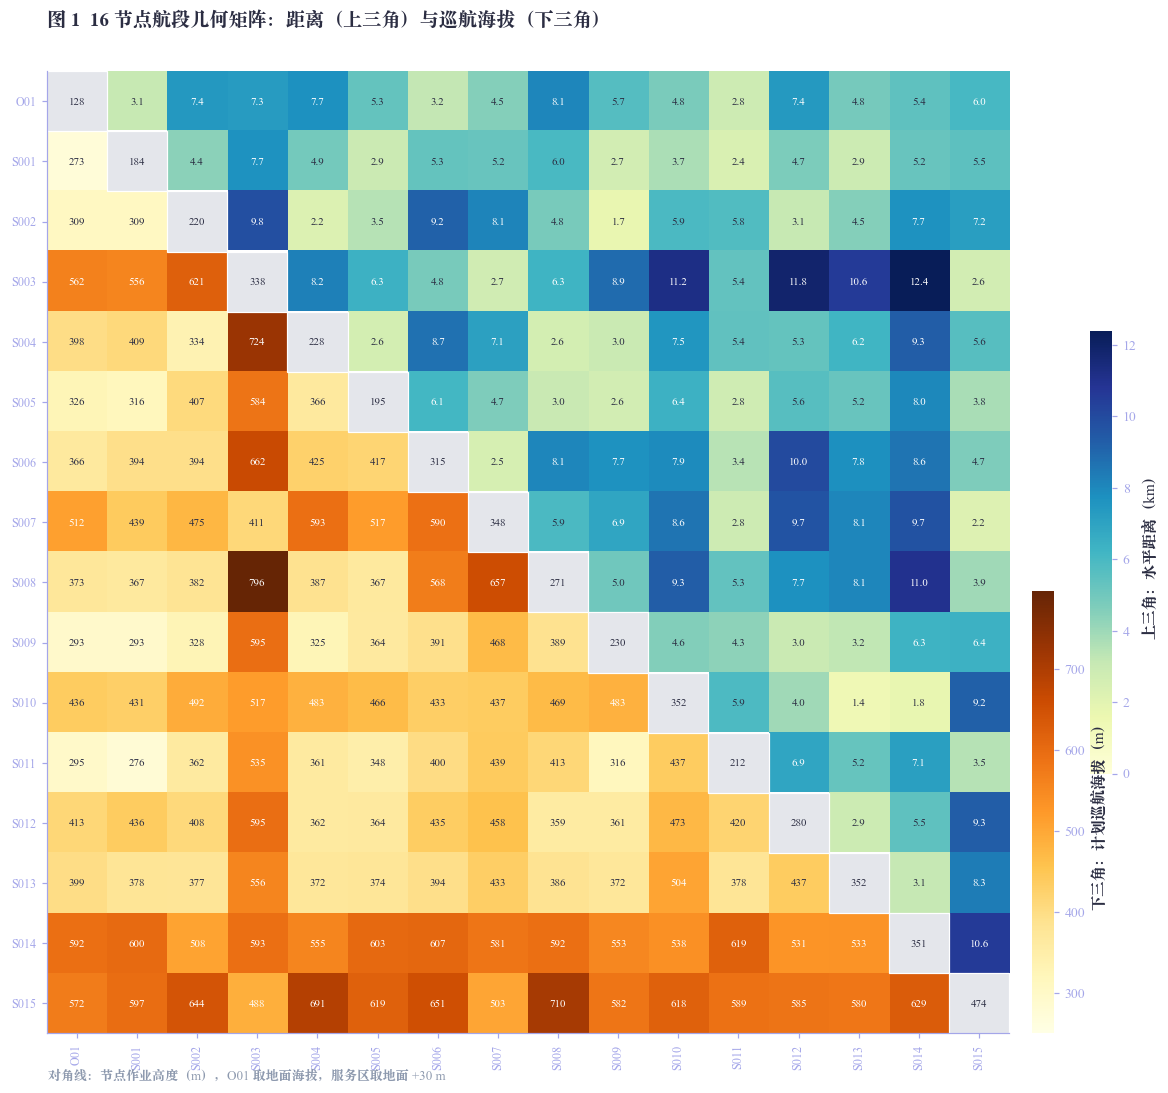

In [6]:
# 图 1：上三角距离、下三角巡航海拔、对角线节点作业高度。
fig,ax=plt.subplots(figsize=(11.5,10)); ax.grid(False)
dist_km=DIST/1000
upper=np.triu(dist_km,1); lower=np.tril(HCRUISE,-1)
cmap_dist=mpl.colormaps['YlGnBu'].copy(); cmap_dist.set_bad((1,1,1,0))
cmap_alt=mpl.colormaps['YlOrBr'].copy(); cmap_alt.set_bad((1,1,1,0))
im1=ax.imshow(np.ma.masked_invalid(np.where(np.triu(np.ones_like(DIST),1),upper,np.nan)),cmap=cmap_dist,vmin=0,vmax=np.nanmax(upper))
im2=ax.imshow(np.ma.masked_invalid(np.where(np.tril(np.ones_like(DIST),-1),lower,np.nan)),cmap=cmap_alt,vmin=250,vmax=np.nanmax(lower))
for i in range(16):
    for j in range(16):
        if i==j:
            ax.add_patch(Rectangle((j-.5,i-.5),1,1,facecolor=PAL['mist'],edgecolor='white'))
            value=ELEV[i]+(H_SERVICE if i else 0)
            ax.text(j,i,f'{value:.0f}',ha='center',va='center',fontsize=7.2,color=PAL['ink'])
        elif i<j:
            ax.text(j,i,f'{dist_km[i,j]:.1f}',ha='center',va='center',fontsize=7.2,color='white' if dist_km[i,j]>6 else PAL['ink'])
        else:
            ax.text(j,i,f'{HCRUISE[i,j]:.0f}',ha='center',va='center',fontsize=7.2,color='white' if HCRUISE[i,j]>480 else PAL['ink'])
ax.set_xticks(range(16),NODE_IDS,rotation=90,fontsize=8); ax.set_yticks(range(16),NODE_IDS,fontsize=8)
cb1=fig.colorbar(im1,ax=ax,fraction=.03,pad=.02,shrink=.46); cb1.set_label('上三角：水平距离（km）'); cb1.outline.set_visible(False)
cb2=fig.colorbar(im2,ax=ax,fraction=.03,pad=.02,shrink=.46,anchor=(0.,0.)); cb2.set_label('下三角：计划巡航海拔（m）'); cb2.outline.set_visible(False)
ax.text(-.48,16.1,'对角线：节点作业高度（m），O01 取地面海拔，服务区取地面 +30 m',fontsize=8.5,color=PAL['grey'],va='top')
ax.set_title('图 1  16 节点航段几何矩阵：距离（上三角）与巡航海拔（下三角）',loc='left',fontsize=12.5,pad=30)
fig.tight_layout(); savefig(fig,'图01_航段几何矩阵'); plt.show()


## 8 图 2：需求与时限结构

调度难点集中在“什么时候必须送到”。按服务区分行、按期望送达时刻布置 80 个货箱；点颜色区分物资类型，点面积表示应急优先系数，深色描边表示硬时限货箱。红色短竖线标出硬截止时刻，右侧列出服务区总质量、箱数和硬时限箱数。首小时内有 8 个服务区、17 个硬时限箱需要保障，且分布于东西两翼。


🖼️ 已保存 q2-main-8000-polish-4000-output/图02_需求时限结构图.png


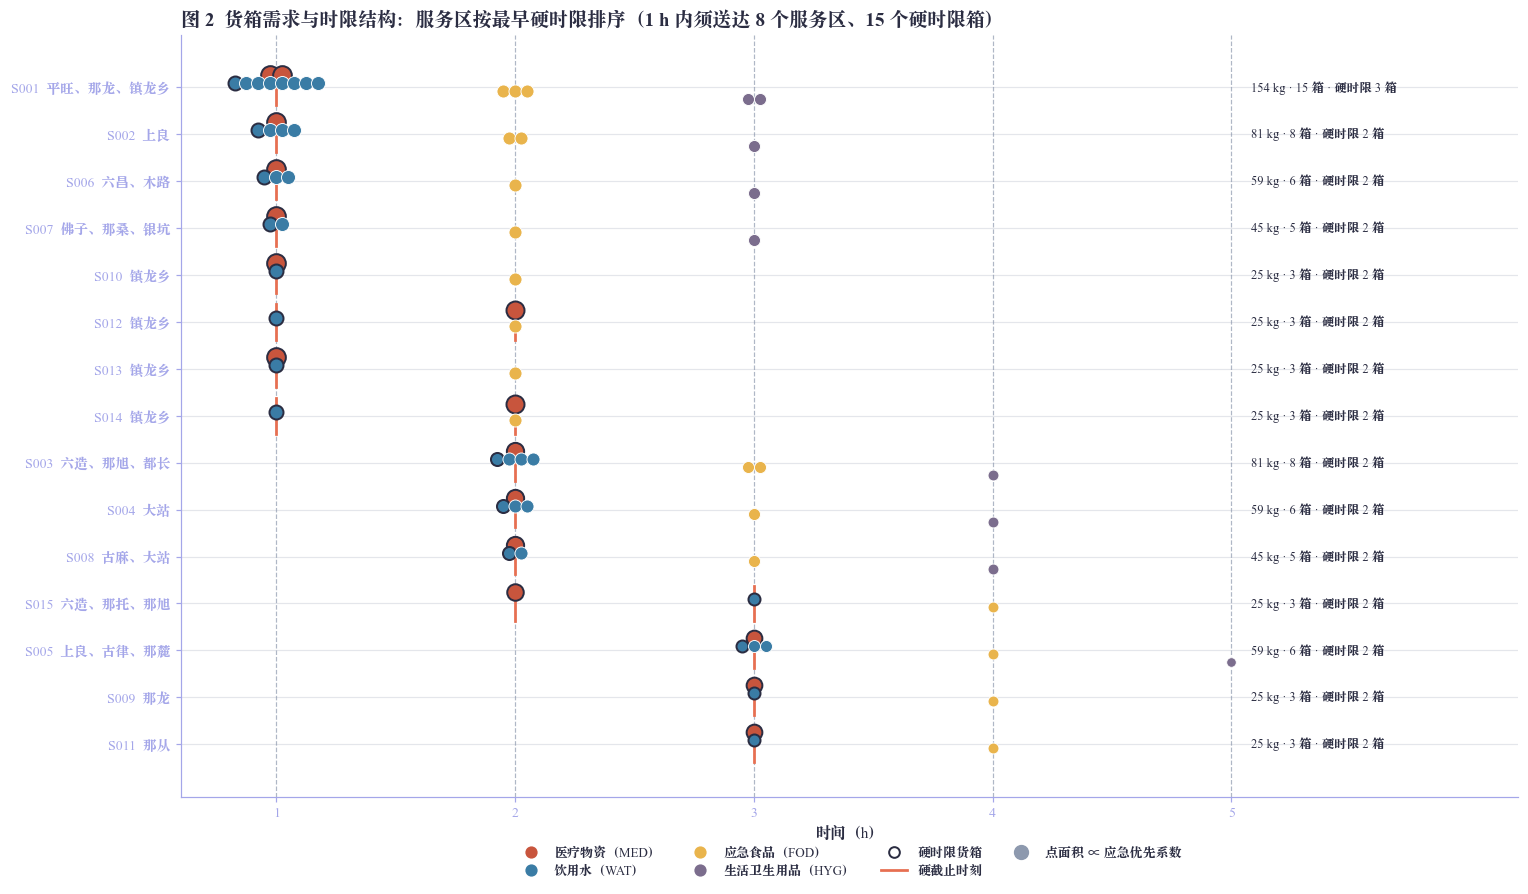

In [7]:
areas_sorted=(boxes.groupby('area').agg(hard=('hard_time','min'),expected=('expected','min')).sort_values(['hard','expected']).index.tolist())
lane={m:k for k,m in enumerate(MAT_ORDER)}
fig,ax=plt.subplots(figsize=(14,8.2))
for yi,a in enumerate(areas_sorted):
    sub=boxes[boxes.area==a]
    ax.axhline(yi,color=PAL['mist'],lw=.8,zorder=1)
    hard_t=sub.hard_time[np.isfinite(sub.hard_time)]
    for t in sorted(set(hard_t)):
        ax.plot([t/3600,t/3600],[yi-.38,yi+.38],color=PAL['coral'],lw=1.8,zorder=3)
    for (mat,te),grp in sub.groupby(['mat','expected']):
        n=len(grp)
        for k,(_,r) in enumerate(grp.iterrows()):
            y=yi+(lane[mat]-1.5)*.17
            x=te/3600+(k-(n-1)/2)*.05
            hard=np.isfinite(r.hard_time)
            ax.scatter(x,y,s=18+5.5*r.priority,color=MAT_COLOR[mat],
                       edgecolor=PAL['ink'] if hard else 'white',linewidths=1.3 if hard else .6,zorder=4)
    total=sub.mass.sum(); nh=int(sub.has_hard.sum())
    ax.text(5.08,yi,f'{total:.0f} kg · {len(sub)} 箱 · 硬时限 {nh} 箱',va='center',fontsize=8.2,color=PAL['ink'])
for h in [1,2,3,4,5]:
    ax.axvline(h,color=PAL['grey'],lw=.8,ls='--',alpha=.7)
labels=[f'{a}  {areas.set_index("id").loc[a,"name"]}' for a in areas_sorted]
ax.set_yticks(range(len(areas_sorted))); ax.set_yticklabels(labels,fontsize=9); ax.invert_yaxis()
ax.set_xlim(.6,6.2); ax.set_xlabel('时间（h）'); ax.set_xticks([1,2,3,4,5]); ax.grid(False)
handles=[Line2D([],[],marker='o',ls='none',color=MAT_COLOR[m],markersize=7,label=f'{m}（{MAT_ABBR[m]}）') for m in MAT_ORDER]
handles += [Line2D([],[],marker='o',ls='none',markerfacecolor='white',markeredgecolor=PAL['ink'],markeredgewidth=1.3,markersize=7,label='硬时限货箱'),
            Line2D([],[],color=PAL['coral'],lw=1.8,label='硬截止时刻'),
            Line2D([],[],marker='o',ls='none',color=PAL['grey'],markersize=9,label='点面积 ∝ 应急优先系数')]
ax.legend(handles=handles,loc='upper center',bbox_to_anchor=(.5,-.05),ncol=4,fontsize=8.5)
narea=boxes[np.isfinite(boxes.hard_time)&(boxes.hard_time<=3600)].area.nunique()
nbox=int((np.isfinite(boxes.hard_time)&(boxes.hard_time<=3600)).sum())
ax.set_title(f'图 2  货箱需求与时限结构：服务区按最早硬时限排序（1 h 内须送达 {narea} 个服务区、{nbox} 个硬时限箱）',loc='left',fontsize=12.5)
fig.tight_layout(); savefig(fig,'图02_需求时限结构图'); plt.show()


## 9 模型建立

### 9.1 整数规划表述（论文用，说明问题结构）

集合：服务区 $S$，货箱 $B$，机型 $G$，无人机 $U_g$，电池 $K_g$，架次 $P$（数量为决策结果，上界取 $|B|$）。决策变量：$x_{bp}\in\{0,1\}$ 表示货箱 $b$ 装入架次 $p$；$y_{pij}\in\{0,1\}$ 表示架次 $p$ 飞航段 $i\to j$；$z_{pu}$、$\zeta_{pk}$ 表示架次 $p$ 由无人机 $u$/电池 $k$ 执行；$t_p^{st}\geq 0$ 为开始时刻；$\pi_{pp'}$ 表示同资源上的先后关系。

$$\min\ (f_T,f_M,f_E,f_N)$$

$$
\begin{aligned}
\text{s.t.}\quad
&\sum_{p\in P}x_{bp}=1,\quad \forall b; \qquad
  \sum_{b}m_bx_{bp}\leq Q_g,\quad
  \sum_{b}v_bx_{bp}\leq V_g,\quad \forall p\in P_g;\\
&\text{流守恒：}\quad
  \sum_j y_{pij}=\sum_j y_{pji}=\mathbf{1}[\text{架次 }p\text{ 访问 }i],\quad
  x_{bp}\leq\sum_j y_{p,a(b),j};\\
&E_p^T=\sum_{(i,j)}y_{pij}E_{gij}(q_{pij})\leq(1-\rho_g)E_g^{use};\qquad
  t_b=t_p^{st}+\delta_{bp};\\
&t_b\leq\bar t_b,\quad \forall b\in B^{hard};\\
&t_{p'}^{st}\geq t_p^{en}-M(1-\pi_{pp'}),\quad\text{同一无人机};\\
&t_{p'}^{st}\geq t_p^{en}+\tau_g^{chg}(s_p)-M(1-\pi_{pp'}),\quad\text{同一电池};\\
&\sum_{u\in U_g}z_{pu}=\sum_{k\in K_g}\zeta_{pk}=1.
\end{aligned}
$$

这是一个带异构多行程、逐箱配送、时间窗、资源充电周转的车辆路径问题（HF-MTVRP-TW with battery turn-over）。80 箱、8 架无人机、14 组电池的规模下，路线变量 $y$ 与时序变量 $\pi$ 的组合呈指数级增长，因此采用“元启发式 + 解码器”的求解框架：搜索只操作“组批与访问顺序”，时序与资源分配交给多项式时间的解码器确定。

### 9.2 架次评估器

给定机型 $g$ 与有序停靠列表 $[(a_1,B_1),\ldots,(a_K,B_K)]$，按第 4 节规则沿航段链累加：载荷递减、逐航段能耗、逐段时间、逐箱送达偏移 $\delta_{bp}$。返回 $E_p^T$、$\tau_p$、$\{\delta_{bp}\}$ 及时间分段（绘制甘特图用）；不满足载质量、体积或能量约束时返回 `None`。


### 9.3 列表调度解码器（Least-Slack-First）

对架次集合 $P$：

1. 计算每个架次的最迟开始时刻 $LST_p=\min_{b\in p}(\bar t_b-\delta_{bp})$（硬时限）与 $LST_p^{exp}=\min_{b\in p}(t_b^{exp}-\delta_{bp})$，按 $(LST_p,LST_p^{exp})$ 升序排列；
2. 依次取架次，选同型中最早可用的无人机 $u$ 与最早可用的电池 $k$，令 $t_p^{st}=\max\{avail(u),avail(k)\}$、$t_p^{en}=t_p^{st}+\tau_p$；
3. 更新 $avail(u)=t_p^{en}$、$avail(k)=t_p^{en}+\tau_g^{chg}(s_p)$，其中 $s_p=1-E_p^T/E_g^{use}$；
4. 得到全部 $t_b$ 后，计算 $f_T,f_M,f_E,f_N$ 与硬时限罚项。

解码器保证任意输出都满足资源约束（无人机不重叠、电池占用与充电不重叠、使用前 SOC 回到 100%），把可行性问题压缩为“时限是否满足”。步骤 1 的排序规则是一个启发式；第 11 节再用序列交换局部搜索对最终方案的排序做精修。


In [8]:
from dataclasses import dataclass
from functools import lru_cache
from collections import Counter
import random

P={g:uav.loc[g] for g in TYPES}
BUDGET={g:(1-P[g].rho)*P[g].E_use for g in TYPES}
SUM_PRIO=float(b_w.sum())

def charge_time(soc,g):
    full=BATT[g][1]; soc=max(0.,min(1.,float(soc)))
    return full*(.65*(.9-soc)/.9+.35) if soc<.9 else full*.35*(1-soc)/.1

def L_eq(p,q): return p.L0-(p.L0-p.LF)*(q/p.Q)**1.5

def box_order(ids):
    return tuple(sorted(ids,key=lambda b:(b_hard[b],-b_w[b],b_exp[b],b)))

@dataclass(frozen=True)
class Sortie:
    g:str
    stops:tuple  # ((节点索引, (箱索引,...)), ...)
    def route(self): return '→'.join(NODE_IDS[i] for i in (0,*[a for a,_ in self.stops],0))
    def box_ids(self): return tuple(b for _,bs in self.stops for b in bs)

@lru_cache(maxsize=240000)
def evaluate(s):
    if not s.stops or len(set(a for a,_ in s.stops))!=len(s.stops): return None
    ids=s.box_ids(); p=P[s.g]; mass=float(sum(b_mass[b] for b in ids)); vol=float(sum(b_vol[b] for b in ids))
    if len(ids)!=len(set(ids)) or mass>p.Q+1e-9 or vol>p.V+1e-9: return None
    if any(not bs or any(b_area[b]!=a for b in bs) for a,bs in s.stops): return None
    t=float(p.t_prep+len(ids)*p.t_load); q=mass; E=0.; prev=0; deliv=[]; segs=[]
    phases=[('prep',0.,t,0)]
    for a,bs in (*s.stops,(0,())):
        t0=t
        t+=LEG_T[s.g][prev,a]
        E+=LEG_A[s.g][prev,a]/L_eq(p,q)+(p.m0+q)*LEG_B[s.g][prev,a]
        segs.append((prev,a,t0,t))
        phases.append(('fly',t0,t,a))
        if a:
            hand0=t
            t+=p.t_hand
            for b in bs:
                t+=p.t_box
                deliv.append((b,t))
                q-=b_mass[b]
            phases.append(('hand',hand0,t,a))
        prev=a
    if E>BUDGET[s.g]+1e-9: return None
    return dict(n=len(ids),mass=mass,vol=vol,E=E,dur=t,deliv=tuple(deliv),segs=tuple(segs),
                phases=tuple(phases),soc=1-E/p.E_use)

example=Sortie('A',((1,(0,)),))
print('单架次示例：',example.route(),evaluate(example))


单架次示例： O01→S001→O01 {'n': 1, 'mass': 3.0, 'vol': 0.012, 'E': np.float64(1.1677945833250916), 'dur': np.float64(1190.8995031364673), 'deliv': ((0, np.float64(848.573084901567)),), 'segs': ((0, 1, 330.0, np.float64(668.573084901567)), (1, 0, np.float64(848.573084901567), np.float64(1190.8995031364673))), 'phases': (('prep', 0.0, 330.0, 0), ('fly', 330.0, np.float64(668.573084901567), 1), ('hand', np.float64(668.573084901567), np.float64(848.573084901567), 1), ('fly', np.float64(848.573084901567), np.float64(1190.8995031364673), 0)), 'soc': np.float64(0.7404900925944241)}


In [9]:
def deadline_key(s):
    ev=evaluate(s)
    hard=[b_hard[b]-off for b,off in ev['deliv'] if np.isfinite(b_hard[b])]
    expected=[b_exp[b]-off for b,off in ev['deliv']]
    return (min(hard),min(expected)) if hard else (math.inf,min(expected))

def decode(sorties,order=None,require_complete=True):
    evs=[evaluate(s) for s in sorties]
    if any(ev is None for ev in evs): return None
    all_ids=[b for s in sorties for b in s.box_ids()]
    if len(all_ids)!=len(set(all_ids)): return None
    if require_complete and (len(all_ids)!=len(BOX_IDS) or set(all_ids)!=set(range(len(BOX_IDS)))): return None
    seq=sorted(range(len(sorties)),key=lambda i:(deadline_key(sorties[i]),i)) if order is None else list(order)
    if sorted(seq)!=list(range(len(sorties))): return None
    u_ready={u:0. for u in UAV_LIST}
    bt_ready={bt:0. for group in BATTS.values() for bt in group}
    rows=[None]*len(sorties); arrival=np.full(len(BOX_IDS),np.nan)
    for k in seq:
        s=sorties[k]; ev=evs[k]
        u=min((u for u in UAV_LIST if UAV_TYPE[u]==s.g),key=lambda x:u_ready[x])
        bt=min(BATTS[s.g],key=lambda x:bt_ready[x])
        st=max(u_ready[u],bt_ready[bt]); en=st+ev['dur']; soc=ev['soc']
        ready=en+charge_time(soc,s.g)
        rows[k]=(u,bt,st,en,soc,ready)
        u_ready[u]=en; bt_ready[bt]=ready
        for b,off in ev['deliv']: arrival[b]=st+off
    assigned=np.isfinite(arrival)
    late=np.zeros(len(BOX_IDS)); late[assigned]=np.maximum(0.,arrival[assigned]-b_exp[assigned])
    hard_mask=assigned & np.isfinite(b_hard)
    hard_late=np.zeros(len(BOX_IDS)); hard_late[hard_mask]=np.maximum(0.,arrival[hard_mask]-b_hard[hard_mask])
    tard=float(np.dot(b_w,late)/SUM_PRIO)
    wdt=float(np.dot(b_w,np.nan_to_num(arrival,nan=0.))/SUM_PRIO)
    hard_sum=float(hard_late.sum()); hard_n=int(np.count_nonzero(hard_late>1e-7))
    makespan=max((row[3] for row in rows),default=0.)
    return dict(schedule=tuple(rows),seq=tuple(seq),arrival=arrival,hard_n=hard_n,
                hard_max=float(hard_late.max(initial=0.)),hard_sum=hard_sum,hard_h=hard_sum/3600,
                tard=tard,wdt=wdt,T=(tard+.1*wdt)/3600,
                avg_delay=tard,avg_arrival=wdt,M=float(makespan),makespan=float(makespan),
                E=float(sum(ev['E'] for ev in evs)),N=len(sorties))

W_REC=dict(T=3.0,M=1.5,E=1.0,N=.5)

def objective(m,W=W_REC):
    if m is None: return math.inf
    return (W['T']*m['T']+W['M']*m['M']/3600+
            W['E']*m['E']/50+W['N']*m['N']/20+
            100*m['hard_h']+5*m['hard_n'])

def metrics_row(m):
    return dict(及时性fT=m['T'],加权平均迟到s=m['tard'],加权平均送达s=m['wdt'],
                完成时间h=m['M']/3600,总能耗kWh=m['E'],架次数=m['N'],硬时限违约箱=m['hard_n'])


## 10 求解算法：自适应大邻域搜索（ALNS）

**基本思想。** 从一个可行解出发，每次迭代用一个“破坏算子”把若干货箱从当前方案中移出，再用一个“修复算子”把它们重新插入（可插入已有架次的已有停靠点、已有架次的新停靠点，或新开架次），得到邻域解；用模拟退火准则决定是否接受；根据各算子近期表现自适应调整被选中概率。

**破坏算子（5 个）：** ① 随机移除；② 最晚送达移除——移出当前迟到/违约代价最大的货箱；③ 同区移除——移出某个服务区的全部货箱，便于重组该区批次；④ 整架次移除；⑤ 末班架次移除——移出结果最晚（决定完成时间）的架次，直接攻击 makespan。每次移除 4–12 箱。

**修复算子（2 个）：** 贪心插入与带噪声的贪心插入。对每个待插箱按“硬时限早、质量大”排序，枚举全部可行插入位置，增量代价为

$$
\Delta=w_E\frac{\Delta E}{50}+w_M\frac{\Delta\tau}{3600}+[\text{新开架次：}\ w_N/20]+\operatorname{罚}(\widehat t_p^{st}+\delta_{bp}>\bar t_b),
$$

其中 $\widehat t_p^{st}$ 用上一次解码得到的架次开始时刻估计硬时限是否会被突破——这是一个代理代价，最终是否接受由完整解码后的 $F$ 决定。噪声版本把 $\Delta$ 乘以 $U(0.85,1.15)$ 以增加多样性。

**局部精修：** 修复后对停靠点不超过 5 个的架次枚举全部访问顺序，取“能耗 + 时长”最小者（TSP 精确求解）；以 20% 概率尝试把架次换成另一可行机型，以平衡不同机型的资源压力。

**接受准则：** 模拟退火，初温使初始解劣化 5% 时接受概率为 $e^{-1}$，再几何降温至初温的 1‰。

**自适应权重：** 每 100 次迭代按得分（新全局最优 3 分、优于当前解 2 分、被接受 1 分）更新 $w\leftarrow0.5w+0.5\,\mathrm{score}/\mathrm{count}$，下限为 0.05。

**复杂度：** 一次完整解码约 0.3 ms，一次迭代约 1.5 ms，8000 次迭代约 15 s，满足“5 分钟内完成”的交付约定。


In [10]:
D_NAMES=('随机移除','最晚送达移除','同区移除','整架次移除','末班架次移除')
R_NAMES=('贪心插入','贪心+噪声插入')

def initial_solution():
    """初始解：逐服务区按 C→B→A 依次装箱（问题一风格的单点架次），仅保证可行。"""
    sorties=[]
    for a in range(1,len(NODE_IDS)):
        pending=sorted([b for b in range(len(BOX_IDS)) if b_area[b]==a],
                       key=lambda b:(b_hard[b],-b_mass[b]))
        while pending:
            selected=None
            for g in ('C','B','A'):
                current=[]
                for b in pending:
                    candidate=Sortie(g,((a,tuple(current+[b])),))
                    if evaluate(candidate) is not None:
                        current.append(b)
                if current:
                    selected=Sortie(g,((a,tuple(current)),))
                    break
            if selected is None:
                raise RuntimeError(f'{NODE_IDS[a]} 尚有货箱不能装入任何机型')
            sorties.append(selected)
            loaded=set(selected.box_ids())
            pending=[b for b in pending if b not in loaded]
    return tuple(sorties)


def remove_boxes(sol,removed):
    gone=set(removed); out=[]
    for s in sol:
        stops=tuple((a,tuple(b for b in bs if b not in gone)) for a,bs in s.stops)
        stops=tuple((a,bs) for a,bs in stops if bs)
        if stops: out.append(Sortie(s.g,stops))
    return tuple(out)

def destroy(sol,m,operator,rng):
    ids=list(range(len(BOX_IDS)))
    nrem=min(len(ids),rng.randint(4,12))
    if operator==D_NAMES[0]:
        return rng.sample(ids,nrem)
    if operator==D_NAMES[1]:
        def penalty(b):
            t=m['arrival'][b]
            return b_w[b]*(t-b_exp[b])+(1e6 if t>b_hard[b] else 0.)
        return sorted(ids,key=penalty,reverse=True)[:nrem]
    if operator==D_NAMES[2]:
        area=rng.randint(1,len(NODE_IDS)-1)
        group=[b for b in ids if b_area[b]==area]
        return group
    if operator==D_NAMES[3]:
        return list(rng.choice(sol).box_ids())
    if operator==D_NAMES[4]:
        k=max(range(len(sol)),key=lambda j:m['schedule'][j][3])
        return list(sol[k].box_ids())
    raise ValueError(operator)

def estimate_starts(sol):
    m=decode(sol,require_complete=False)
    if m is None: return {}
    est={k:m['schedule'][k][2] for k in range(len(sol))}
    uav_av={u:0. for u in UAV_LIST}
    for u,bt,st,en,soc,ready in m['schedule']:
        uav_av[u]=max(uav_av[u],en)
    for g in TYPES:
        est[('new',g)]=min(uav_av[u] for u in UAV_LIST if UAV_TYPE[u]==g)
    return est

def insertion_candidates(sol,b):
    out=[]; area=int(b_area[b])
    for k,s in enumerate(sol):
        old_areas=[a for a,_ in s.stops]
        if area in old_areas:
            pos=old_areas.index(area)
            stops=list(s.stops); a,bs=stops[pos]
            stops[pos]=(a,tuple((*bs,b)))
            cand=Sortie(s.g,tuple(stops))
            if evaluate(cand) is not None: out.append((k,cand))
        elif len(s.stops)<5:
            for pos in range(len(s.stops)+1):
                stops=list(s.stops); stops.insert(pos,(area,(b,)))
                cand=Sortie(s.g,tuple(stops))
                if evaluate(cand) is not None: out.append((k,cand))
    for g in TYPES:
        cand=Sortie(g,((area,(b,)),))
        if evaluate(cand) is not None: out.append((len(sol),cand))
    return out

def insertion_best(sol,b,est_start,W,noise,rng):
    best=(math.inf,None)
    def hard_penalty(st,ev):
        cost=0.
        for bx,off in ev['deliv']:
            if np.isfinite(b_hard[bx]) and st+off>b_hard[bx]:
                cost+=100*(st+off-b_hard[bx])/3600+5
        return cost
    for k,cand in insertion_candidates(sol,b):
        ev=evaluate(cand); old=evaluate(sol[k]) if k<len(sol) else None
        start=est_start.get(k,0.)
        if old is None:
            cost=W['E']*ev['E']/50+W['M']*ev['dur']/3600+W['N']/20
        else:
            cost=W['E']*(ev['E']-old['E'])/50+W['M']*(ev['dur']-old['dur'])/3600
        cost+=hard_penalty(start,ev)
        if noise: cost*=rng.uniform(.85,1.15)
        if cost<best[0]: best=(cost,(k,cand))
    return best[1]

def repair(partial,removed,operator,W,rng):
    sol=tuple(partial); pending=list(dict.fromkeys(removed))
    pending.sort(key=lambda b:(b_hard[b],-b_mass[b]))
    est=estimate_starts(sol)
    while pending:
        b=pending.pop(0)
        result=insertion_best(sol,b,est,W,operator==R_NAMES[1],rng)
        if result is None: return None
        k,cand=result
        if k==len(sol): sol=sol+(cand,)
        else: sol=sol[:k]+(cand,)+sol[k+1:]
        est=estimate_starts(sol)
    return sol

def reorder_stops(s):
    if len(s.stops)<=1 or len(s.stops)>5: return s
    best=None
    for perm in itertools.permutations(s.stops):
        ev=evaluate(Sortie(s.g,tuple(perm)))
        if ev is None: continue
        score=ev['E']+.5*ev['dur']/3600
        if best is None or score<best[0]: best=(score,tuple(perm))
    return Sortie(s.g,best[1]) if best else s

def run_alns(start,W=W_REC,iters=8000,seed=0,W_track=None):
    rng=random.Random(seed)
    cur=tuple(start); cur_m=decode(cur); cur_f=objective(cur_m,W)
    best=cur; best_m=cur_m; best_f=cur_f
    tracked=(objective(cur_m,W_track),cur,cur_m) if W_track and cur_m['hard_n']==0 else None
    dw={x:1. for x in D_NAMES}; rw={x:1. for x in R_NAMES}
    dscore=Counter(); rscore=Counter(); dcount=Counter(); rcount=Counter()
    fref=objective(dict(cur_m,hard_h=0.,hard_n=0),W)
    temp=max(fref*.05,1e-6); temp_end=max(fref*.0005,1e-8)
    alpha=(temp_end/temp)**(1/max(1,iters))
    hist=[]; whist=[(0,dict(dw))]; explored=set()
    for it in range(iters):
        est=estimate_starts(cur)
        dop=rng.choices(D_NAMES,weights=[dw[x] for x in D_NAMES],k=1)[0]
        rop=rng.choices(R_NAMES,weights=[rw[x] for x in R_NAMES],k=1)[0]
        removed=destroy(cur,cur_m,dop,rng)
        partial=remove_boxes(cur,removed)
        trial=repair(partial,removed,rop,W,rng)
        if trial is not None:
            trial=tuple(reorder_stops(s) for s in trial)
            if trial and rng.random()<.20:
                k=rng.randrange(len(trial)); s=trial[k]
                choices=[g for g in TYPES if g!=s.g]
                g2=rng.choice(choices); alt=Sortie(g2,s.stops)
                if evaluate(alt) is not None: trial=trial[:k]+(alt,)+trial[k+1:]
            nm=decode(trial); nf=objective(nm,W) if nm is not None else math.inf
        else:
            nm=None; nf=math.inf
        score=0
        if nm is not None:
            if W_track and nm['hard_n']==0:
                ft=objective(nm,W_track)
                if tracked is None or ft<tracked[0]-1e-9: tracked=(ft,trial,nm)
            if nf<best_f-1e-9:
                best,best_m,best_f=trial,nm,nf; score=3
            if nf<cur_f-1e-9 or rng.random()<math.exp(-(nf-cur_f)/max(temp,1e-12)):
                if score==0: score=2 if nf<cur_f-1e-9 else 1
                cur,cur_m,cur_f=trial,nm,nf
                if cur_m['hard_n']==0:
                    explored.add((round(cur_m['T'],6),round(cur_m['M']/3600,6),
                                  round(cur_m['E'],6),int(cur_m['N'])))
            dscore[dop]+=score; rscore[rop]+=score; dcount[dop]+=1; rcount[rop]+=1
        if (it+1)%100==0:
            for x in D_NAMES:
                if dcount[x]: dw[x]=max(.05,.5*dw[x]+.5*dscore[x]/dcount[x])
            for x in R_NAMES:
                if rcount[x]: rw[x]=max(.05,.5*rw[x]+.5*rscore[x]/rcount[x])
            dscore.clear(); rscore.clear(); dcount.clear(); rcount.clear()
            whist.append((it+1,dict(dw)))
        temp*=alpha
        hist.append((it+1,cur_f,best_f,best_m['M'],best_m['E'],best_m['N'],best_m['T'],best_m['hard_n']))
    return best,best_m,best_f,hist,whist,explored,tracked

def polish_order(sol,W=W_REC,trials=4000,seed=1):
    order=list(sorted(range(len(sol)),key=lambda k:(deadline_key(sol[k]),k)))
    best_m=decode(sol,order); best_f=objective(best_m,W)
    rng=random.Random(seed)
    if len(order)<2: return order,best_m,best_f
    for _ in range(trials):
        i,j=rng.sample(range(len(order)),2)
        candidate=order.copy(); candidate[i],candidate[j]=candidate[j],candidate[i]
        mm=decode(sol,candidate); f=objective(mm,W)
        if f<best_f-1e-9: order,best_m,best_f=candidate,mm,f
    return order,best_m,best_f

print('ALNS 已定义。')


ALNS 已定义。


## 11 求解推荐方案（权重 (3, 1.5, 1, 0.5)）与图 3

先构造初始解（问题一风格的单点架次，只保证可行），再运行 8000 次 ALNS 迭代，最后对排队顺序做 4000 次交换精修。图 3 记录搜索过程：(a) 当前解/最优解目标值；(b) 五个破坏算子权重的自适应演化；(c) 最优解四个指标随迭代的变化。

初始解：18 架次，完成时间 5.16 h，硬时限违约 23 箱，F=1942.35


ALNS 8000 次迭代用时 32.5 s，F=5.515，及时性fT=0.109, 加权平均迟到s=71.467, 加权平均送达s=3207.379, 完成时间h=2.179, 总能耗kWh=69.724, 架次数=21, 硬时限违约箱=0


排队顺序精修用时 0.2 s，F=5.477，及时性fT=0.092, 加权平均迟到s=10.688, 加权平均送达s=3197.121, 完成时间h=2.188, 总能耗kWh=69.724, 架次数=21, 硬时限违约箱=0


🖼️ 已保存 q2-main-8000-polish-4000-output/图03_ALNS搜索过程.png


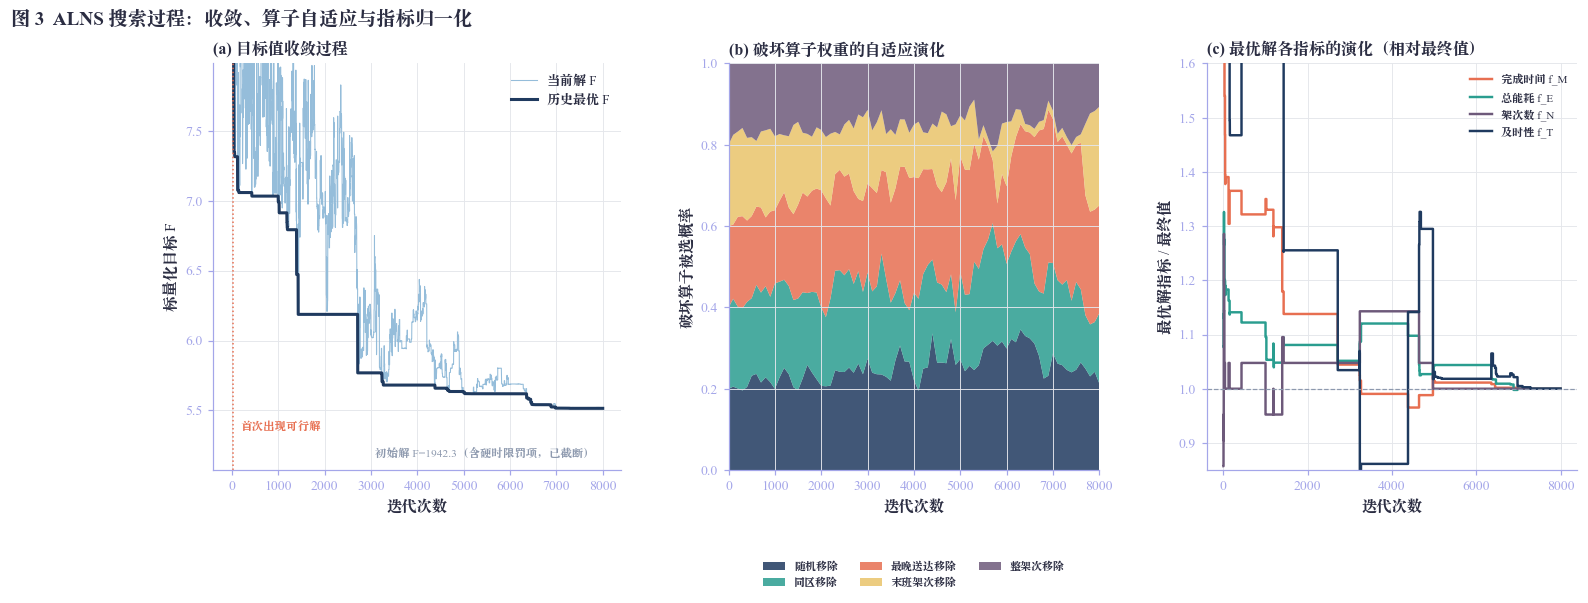

In [11]:
ITERS_MAIN,ITERS_SCEN = 8000, 3000
POLISH_SCEN = 2000
t0 = time.time()
sol0 = initial_solution(); m_init = decode(sol0)
print(f'初始解：{m_init["N"]} 架次，完成时间 {m_init["makespan"]/3600:.2f} h，硬时限违约 {m_init["hard_n"]} 箱，F={objective(m_init,W_REC):.2f}')
best,best_m,best_f,HIST,WHIST,EXPL,TRACK_MAIN = run_alns(sol0,W_REC,iters=ITERS_MAIN,seed=2026)
t1 = time.time()
print(f'ALNS {ITERS_MAIN} 次迭代用时 {t1-t0:.1f} s，F={best_f:.3f}，' + ', '.join(f'{k}={v:.3f}' if isinstance(v,float) else f'{k}={v}' for k,v in metrics_row(best_m).items()))
MAIN_RAW = best_m
ORDER,best_m,best_f = polish_order(best,W_REC)
MAIN_ORDER = ORDER
print(f'排队顺序精修用时 {time.time()-t1:.1f} s，F={best_f:.3f}，' + ', '.join(f'{k}={v:.3f}' if isinstance(v,float) else f'{k}={v}' for k,v in metrics_row(best_m).items()))
MAIN_SOL,MAIN_M,MAIN_F = best,best_m,best_f

# ===== 图 3：ALNS 搜索过程 =====
H = np.array([(h[0],h[1],h[2],h[3],h[4],h[5],h[6]) for h in HIST],float)
fig = plt.figure(figsize=(16,4.8)); gs = fig.add_gridspec(1,3,width_ratios=[1.1,1.0,1.0],wspace=.28)
ax = fig.add_subplot(gs[0])
ax.plot(H[:,0],H[:,1],color=PAL['sky'],lw=.7,alpha=.9,label='当前解 F')
ax.plot(H[:,0],H[:,2],color=PAL['indigo'],lw=2.0,label='历史最优 F')
y_lo = H[:,2].min()*.92; y_hi = np.percentile(H[200:,1],97)
ax.set_ylim(y_lo,y_hi); ax.set_xlabel('迭代次数'); ax.set_ylabel('标量化目标 F'); ax.legend(loc='upper right')
ax.text(ITERS_MAIN*.98,y_lo+.03*(y_hi-y_lo),f'初始解 F={objective(m_init,W_REC):.1f}（含硬时限罚项，已截断）',fontsize=7.5,color=PAL['grey'],ha='right')
first_feas = next((int(h[0]) for h in HIST if h[7]==0),None)
if first_feas is not None:
    ax.axvline(first_feas,color=PAL['coral'],ls=':',lw=1)
    ax.text(first_feas+ITERS_MAIN*.02,y_lo+.10*(y_hi-y_lo),'首次出现可行解',fontsize=7.5,color=PAL['coral'],ha='left')
ax.set_title('(a) 目标值收敛过程',loc='left',fontsize=10.5)

ax = fig.add_subplot(gs[1])
wh = np.array([x[0] for x in WHIST],float)
plot_names = ('随机移除','同区移除','最晚送达移除','末班架次移除','整架次移除')
wv = np.array([[x[1][name] for name in plot_names] for x in WHIST],float)
wp = wv/wv.sum(axis=1,keepdims=True)
ax.stackplot(wh,wp.T,labels=plot_names,colors=[PAL['indigo'],PAL['teal'],PAL['coral'],PAL['gold'],PAL['plum']],alpha=.85)
ax.set_xlim(0,ITERS_MAIN); ax.set_ylim(0,1); ax.set_xlabel('迭代次数'); ax.set_ylabel('破坏算子被选概率')
ax.legend(loc='upper center',bbox_to_anchor=(.5,-.20),ncol=3,fontsize=7.2)
ax.set_title('(b) 破坏算子权重的自适应演化',loc='left',fontsize=10.5)

ax = fig.add_subplot(gs[2])
fin = np.maximum(H[-1,3:7],1e-12)
labels = ['完成时间 f_M','总能耗 f_E','架次数 f_N','及时性 f_T']
colors = [PAL['coral'],PAL['teal'],PAL['plum'],PAL['indigo']]
for k,(lab,col) in enumerate(zip(labels,colors)):
    ax.step(H[:,0],H[:,3+k]/fin[k],where='post',color=col,lw=1.6,label=lab)
ax.axhline(1.0,color=PAL['grey'],lw=.8,ls='--')
ax.set_xlabel('迭代次数'); ax.set_ylabel('最优解指标 / 最终值'); ax.set_ylim(.85,1.6)
ax.legend(fontsize=7.3,loc='upper right')
ax.set_title('(c) 最优解各指标的演化（相对最终值）',loc='left',fontsize=10.5)
fig.suptitle('图 3  ALNS 搜索过程：收敛、算子自适应与指标归一化',x=.01,ha='left',fontsize=12.5,fontweight='bold')
fig.tight_layout(rect=[0,0,1,.93]); savefig(fig,'图03_ALNS搜索过程'); plt.show()


## 12 权衡情景搜索与推荐方案的最终确定

以主搜索得到的解为热启动，分别把四个指标之一的权重放大（其余缩小），各运行 3000 次 ALNS + 顺序精修，得到“及时性优先 / 完成时间优先 / 能耗优先 / 架次优先”四个端点方案。四次情景搜索同时按推荐权重跟踪途中遇到的最优解——它们相当于对推荐权重问题的四次多样化重启，若其中找到比主搜索更好的解，就以其作为最终推荐方案（保证推荐方案是全部搜索中推荐权重下最优的可行解）。

In [12]:
SCEN_W={
    '及时性优先':dict(T=8.,M=1.,E=.5,N=.25),
    '完成时间优先':dict(T=1.,M=6.,E=.5,N=.25),
    '能耗优先':dict(T=1.,M=.5,E=6.,N=.5),
    '架次优先':dict(T=1.,M=.5,E=1.,N=6.),
}
scen_sol={}; explored_all=list(EXPL); cands=[(MAIN_F,MAIN_SOL,MAIN_M,'主搜索')]
scen_rows=[]
t0=time.time()
for k,(name,W) in enumerate(SCEN_W.items()):
    sol,m,f,h,wh,ex,track=run_alns(MAIN_SOL,W,iters=ITERS_SCEN,seed=7+k,W_track=W_REC)
    _,m,f=polish_order(sol,W,trials=200)
    explored_all += ex; scen_sol[name]=(sol,m)
    if track:
        _,tm,tf=polish_order(track[1],W_REC,trials=200)
        cands.append((tf,track[1],tm,f'{name}情景跟踪'))
    print(name+':',metrics_row(m))
print('权衡情景求解用时 s：',round(time.time()-t0,1))
cands.sort(key=lambda c:c[0])
PLAN_F,PLAN_SORTIES,PLAN_M,PLAN_SRC=cands[0]
print('推荐权重下各候选：','；'.join(f'{c[3]} F={c[0]:.3f}' for c in cands))
print('→ 最终推荐方案来自「'+PLAN_SRC+'」，F=',round(PLAN_F,3),metrics_row(PLAN_M))
SCEN={'推荐 (3,1.5,1,0.5)':(W_REC,PLAN_SORTIES,PLAN_M)}
SCEN.update({name:(SCEN_W[name],scen_sol[name][0],scen_sol[name][1]) for name in SCEN_W})
scen_rows=[]
for name,(W,sol,m) in SCEN.items():
    row=dict(情景=name,**{kk:f'{v:.2f}' for kk,v in W.items()}); row.update(metrics_row(m))
    row['机型构成']=dict(Counter(s.g for s in sol))
    scen_rows.append(row)
scen_df=pd.DataFrame(scen_rows).set_index('情景'); display(scen_df.round(3))
pts=np.asarray(sorted(set(explored_all)),float); nd=np.ones(len(pts),bool)
for i in range(len(pts)):
    if nd[i]:
        dom=np.all(pts<=pts[i]+1e-9,axis=1)&np.any(pts<pts[i]-1e-9,axis=1)
        if dom.any(): nd[i]=False
nd_df=pd.DataFrame(pts[nd],columns=['及时性fT','完成时间h','总能耗kWh','架次数']).sort_values('完成时间h')
print(f'搜索过程中记录到 {len(pts)} 个互不相同的可行解，其中四维非支配解 {int(nd.sum())} 个')
display(nd_df.head(25).round(3))

及时性优先: {'及时性fT': 0.08467360253576071, '加权平均迟到s': 16.393711206526003, '加权平均送达s': 2884.312579222126, '完成时间h': 2.209988710264347, '总能耗kWh': 72.2648533043155, '架次数': 22, '硬时限违约箱': 0}


完成时间优先: {'及时性fT': 0.12103625288795333, '加权平均迟到s': 141.19989501842332, '加权平均送达s': 2945.3061537820868, '完成时间h': 1.8919852715518601, '总能耗kWh': 72.92644584941283, '架次数': 23, '硬时限违约箱': 0}


能耗优先: {'及时性fT': 0.14708824654782515, '加权平均迟到s': 129.9436802561908, '加权平均送达s': 3995.740073159797, '完成时间h': 2.6545633915472555, '总能耗kWh': 63.56173079986824, '架次数': 19, '硬时限违约箱': 0}


架次优先: {'及时性fT': 0.22768991801392366, '加权平均迟到s': 407.66362270872594, '加权平均送达s': 4120.200821413992, '完成时间h': 2.938008483867339, '总能耗kWh': 69.69652707523845, '架次数': 17, '硬时限违约箱': 0}
权衡情景求解用时 s： 51.2
推荐权重下各候选： 完成时间优先情景跟踪 F=5.239；主搜索 F=5.477；及时性优先情景跟踪 F=5.477；能耗优先情景跟踪 F=5.477；架次优先情景跟踪 F=5.477
→ 最终推荐方案来自「完成时间优先情景跟踪」，F= 5.239 {'及时性fT': 0.09550561807467825, '加权平均迟到s': 49.25868768193174, '加权平均送达s': 2945.6153738690996, '完成时间h': 1.9769978193326385, '总能耗kWh': 71.83934428230747, '架次数': 22, '硬时限违约箱': 0}


,T,M,E,N,及时性fT,加权平均迟到s,加权平均送达s,完成时间h,总能耗kWh,架次数,硬时限违约箱,机型构成
情景,,,,,,,,,,,,
"推荐 (3,1.5,1,0.5)",3.00,1.50,1.00,0.50,0.096,49.259,2945.615,1.977,71.839,22,0,"{'C': 6, 'A': 9, 'B': 7}"
及时性优先,8.00,1.00,0.50,0.25,0.085,16.394,2884.313,2.210,72.265,22,0,"{'C': 6, 'A': 9, 'B': 7}"
完成时间优先,1.00,6.00,0.50,0.25,0.121,141.200,2945.306,1.892,72.926,23,0,"{'A': 10, 'C': 6, 'B': 7}"
能耗优先,1.00,0.50,6.00,0.50,0.147,129.944,3995.740,2.655,63.562,19,0,"{'C': 7, 'B': 11, 'A': 1}"
架次优先,1.00,0.50,1.00,6.00,0.228,407.664,4120.201,2.938,69.697,17,0,"{'C': 8, 'B': 7, 'A': 2}"


搜索过程中记录到 7080 个互不相同的可行解，其中四维非支配解 93 个


,及时性fT,完成时间h,总能耗kWh,架次数
36,0.130,1.922,72.926,23.0
33,0.125,1.931,73.694,23.0
34,0.127,1.931,72.883,23.0
35,0.130,1.931,72.787,23.0
30,0.121,1.935,72.246,23.0
26,0.114,1.945,72.346,23.0
25,0.114,1.990,72.908,23.0
47,0.151,2.013,72.889,22.0
46,0.151,2.013,72.914,22.0
50,0.154,2.013,72.862,22.0


## 13 推荐方案：架次安排与逐箱送达时刻

按实际开始时刻为架次重新编号。结果表给出架次的无人机、电池、路线、载荷、能量、SOC 与占用时间；逐箱表给出送达时刻、期望时刻、硬时限余量及迟到情况；电池表记录任务占用和两阶段充电时间。


In [13]:
def build_tables(sorties,m):
    seq=sorted(range(len(sorties)),key=lambda k:(m['schedule'][k][2],k))
    pid={k:f'P{rank+1:02d}' for rank,k in enumerate(seq)}
    runs=[]; deliveries=[]; segments=[]; batteries=[]
    for k in seq:
        s=sorties[k]; ev=evaluate(s); u,bt,st,en,soc,ready=m['schedule'][k]
        prep=float(P[s.g].t_prep+ev['n']*P[s.g].t_load)
        fast=float(BATT[s.g][1]*.65*max(0.,.9-soc)/.9) if soc<.9 else 0.
        runs.append(dict(架次=pid[k],机型=s.g,无人机=u,电池=bt,路线=s.route(),停靠点=len(s.stops),
                         箱数=ev['n'],载荷kg=ev['mass'],体积m3=ev['vol'],能耗kWh=ev['E'],
                         能量预算kWh=BUDGET[s.g],返航SOC=soc,开始时刻s=st,起飞时刻s=st+prep,
                         结束时刻s=en,持续s=ev['dur'],充电结束s=ready,货箱='、'.join(BOX_IDS[b] for b in s.box_ids())))
        batteries.append(dict(电池=bt,机型=s.g,架次=pid[k],无人机=u,使用开始s=st,使用结束s=en,
                              充电开始s=en,快充结束s=en+fast,充电结束s=ready,结束SOC=soc))
        for phase,t0,t1,node in ev['phases']:
            segments.append(dict(架次=pid[k],无人机=u,机型=s.g,阶段=phase,开始s=st+t0,结束s=st+t1,
                                 起点=NODE_IDS[0 if phase=='prep' else node],终点=NODE_IDS[node]))
        for b,off in ev['deliv']:
            t=st+off; hard=b_hard[b]
            is_first=bool(box_data.iloc[b]['first'])
            deadline_kind='首批箱' if is_first else ('医疗' if b_mat[b]=='医疗物资' else '—')
            deliveries.append(dict(货箱编号=BOX_IDS[b],服务区=NODE_IDS[b_area[b]],物资类型=b_mat[b],
                                   质量kg=b_mass[b],架次=pid[k],无人机=u,送达时刻s=t,期望时刻s=b_exp[b],
                                   硬时限s=hard if np.isfinite(hard) else np.nan,
                                   时限类型=deadline_kind,
                                   硬时限余量s=hard-t if np.isfinite(hard) else np.nan,
                                   迟到s=max(0.,t-b_exp[b]),是否迟到=t>b_exp[b]+1e-7))
    plan_df=pd.DataFrame(runs).sort_values('开始时刻s').reset_index(drop=True)
    box_df=pd.DataFrame(deliveries).sort_values(['服务区','货箱编号']).reset_index(drop=True)
    seg_df=pd.DataFrame(segments)
    bat_df=pd.DataFrame(batteries).sort_values(['电池','使用开始s']).reset_index(drop=True)
    return plan_df,box_df,seg_df,bat_df,pid

plan_df,box_df,seg_df,bat_df,PID=build_tables(PLAN_SORTIES,PLAN_M)
print('推荐方案架次表：'); display(plan_df.drop(columns=['货箱']).round(2))
print('逐箱送达时刻表（前 20 行；完整 80 箱保留在 box_df）：'); display(box_df.head(20).round(1))
print('电池占用与充电时间线：'); display(bat_df.round(1))
print('机型架次数：',dict(Counter(plan_df['机型'])),'；多点架次：',int((plan_df['停靠点']>1).sum()))
print('无人机使用：',dict(Counter(plan_df['无人机'])),'；电池使用：',dict(Counter(plan_df['电池'])))
late_n=int(box_df['是否迟到'].sum())
hard_n=int((box_df['硬时限s'].notna()&box_df['硬时限余量s'].lt(-1e-7)).sum())
min_slack=float(box_df.loc[box_df['硬时限s'].notna(),'硬时限余量s'].min())
print(f'及时性：迟到货箱 {late_n} 箱，硬时限违约 {hard_n} 箱；硬时限箱最小提前量 {min_slack/60:.1f} min')
print(f'完成时间 {PLAN_M["M"]/3600:.3f} h，总能耗 {PLAN_M["E"]:.2f} kWh，{PLAN_M["N"]} 架次')


推荐方案架次表：


,架次,机型,无人机,电池,路线,停靠点,箱数,载荷kg,体积m3,能耗kWh,能量预算kWh,返航SOC,开始时刻s,起飞时刻s,结束时刻s,持续s,充电结束s
0,P01,A,U02,A-B2,O01→S003→S015→O01,2,3,20.0,0.05,3.30,3.6,0.27,0.00,390.00,2603.33,2603.33,4055.86
1,P02,C,U08,C-B2,O01→S001→O01,1,8,78.0,0.19,3.00,6.4,0.63,0.00,540.00,1626.17,1626.17,3270.86
2,P03,A,U04,A-B4,O01→S001→S008→O01,2,2,17.0,0.04,3.28,3.6,0.27,0.00,360.00,2460.55,2460.55,3908.70
3,P04,A,U01,A-B1,O01→S007→O01,1,2,17.0,0.04,1.91,3.6,0.58,0.00,360.00,1727.42,1727.42,2777.86
4,P05,B,U05,B-B1,O01→S014→S010→O01,2,3,25.0,0.07,2.31,3.2,0.42,0.00,390.00,2116.04,2116.04,3784.99
5,P06,B,U06,B-B2,O01→S012→O01,1,3,25.0,0.07,2.75,3.2,0.31,0.00,390.00,1922.74,1922.74,3782.12
6,P07,A,U03,A-B3,O01→S006→O01,1,2,22.0,0.06,1.36,3.6,0.70,0.00,360.00,1313.48,1313.48,2205.51
7,P08,C,U07,C-B1,O01→S002→O01,1,6,67.0,0.15,6.28,6.4,0.21,0.00,480.00,2107.81,2107.81,4642.20
8,P09,A,U03,A-B5,O01→S008→O01,1,2,22.0,0.06,3.31,3.6,0.26,1313.48,1673.48,3484.61,2171.13,4940.38
9,P10,C,U08,C-B3,O01→S007→S003→O01,2,7,70.0,0.21,6.08,6.4,0.24,1626.17,2136.17,4319.76,2693.59,6798.79


逐箱送达时刻表（前 20 行；完整 80 箱保留在 box_df）：


,货箱编号,服务区,物资类型,质量kg,架次,无人机,送达时刻s,期望时刻s,硬时限s,时限类型,硬时限余量s,迟到s,是否迟到
0,S001-FOD-01,S001,应急食品,8.0,P21,U07,5730.2,7200.0,NaN,—,NaN,0.0,False
1,S001-FOD-02,S001,应急食品,8.0,P02,U08,1098.3,7200.0,NaN,—,NaN,0.0,False
2,S001-FOD-03,S001,应急食品,8.0,P02,U08,1170.3,7200.0,NaN,—,NaN,0.0,False
3,S001-HYG-01,S001,生活卫生用品,6.0,P21,U07,5694.2,10800.0,NaN,—,NaN,0.0,False
4,S001-HYG-02,S001,生活卫生用品,6.0,P21,U07,5766.2,10800.0,NaN,—,NaN,0.0,False
5,S001-MED-01,S001,医疗物资,3.0,P02,U08,1314.3,3600.0,3600.0,首批箱,2285.7,0.0,False
6,S001-MED-02,S001,医疗物资,3.0,P02,U08,1062.3,3600.0,3600.0,医疗,2537.7,0.0,False
7,S001-WAT-01,S001,饮用水,14.0,P02,U08,1242.3,3600.0,3600.0,首批箱,2357.7,0.0,False
8,S001-WAT-02,S001,饮用水,14.0,P03,U04,878.6,3600.0,NaN,—,NaN,0.0,False
9,S001-WAT-03,S001,饮用水,14.0,P02,U08,1278.3,3600.0,NaN,—,NaN,0.0,False


电池占用与充电时间线：


,电池,机型,架次,无人机,使用开始s,使用结束s,充电开始s,快充结束s,充电结束s,结束SOC
0,A-B1,A,P04,U01,0.0,1727.4,1727.4,2147.9,2777.9,0.6
1,A-B1,A,P16,U02,2777.9,5040.5,5040.5,5801.3,6431.3,0.3
2,A-B2,A,P01,U02,0.0,2603.3,2603.3,3425.9,4055.9,0.3
3,A-B3,A,P07,U03,0.0,1313.5,1313.5,1575.5,2205.5,0.7
4,A-B3,A,P15,U04,2460.5,4429.1,4429.1,5038.0,5668.0,0.4
5,A-B4,A,P03,U04,0.0,2460.5,2460.5,3278.7,3908.7,0.3
6,A-B4,A,P18,U03,3908.7,5600.9,5600.9,6104.4,6734.4,0.5
7,A-B5,A,P09,U03,1313.5,3484.6,3484.6,4310.4,4940.4,0.3
8,A-B6,A,P11,U01,1727.4,3631.3,3631.3,4160.0,4790.0,0.5
9,B-B1,B,P05,U05,0.0,2116.0,2116.0,2945.0,3785.0,0.4


机型架次数： {'A': 9, 'C': 6, 'B': 7} ；多点架次： 9
无人机使用： {'U02': 2, 'U08': 3, 'U04': 2, 'U01': 2, 'U05': 4, 'U06': 3, 'U03': 3, 'U07': 3} ；电池使用： {'A-B2': 1, 'C-B2': 2, 'A-B4': 2, 'A-B1': 2, 'B-B1': 2, 'B-B2': 2, 'A-B3': 2, 'C-B1': 2, 'A-B5': 1, 'C-B3': 1, 'A-B6': 1, 'B-B3': 1, 'C-B4': 1, 'B-B4': 2}
及时性：迟到货箱 2 箱，硬时限违约 0 箱；硬时限箱最小提前量 5.5 min
完成时间 1.977 h，总能耗 71.84 kWh，22 架次


## 14 图 4：推荐方案航线图

底图沿用问题一的山体阴影（降低对比度以突出航线）。每个架次的航段画成弧形箭头，颜色=执行无人机（同机型为同一色系，深浅区分个体），弧度按架次编号错开避免重叠；右侧为架次清单（编号、无人机、路线、起飞时刻）。多点架次呈现为“链式”箭头，可以直观看到东翼（S002/S004/S009/S012）与西翼（S003/S007/S015）如何被串联。

🖼️ 已保存 q2-figure4-render/图04_推荐方案航线图.png


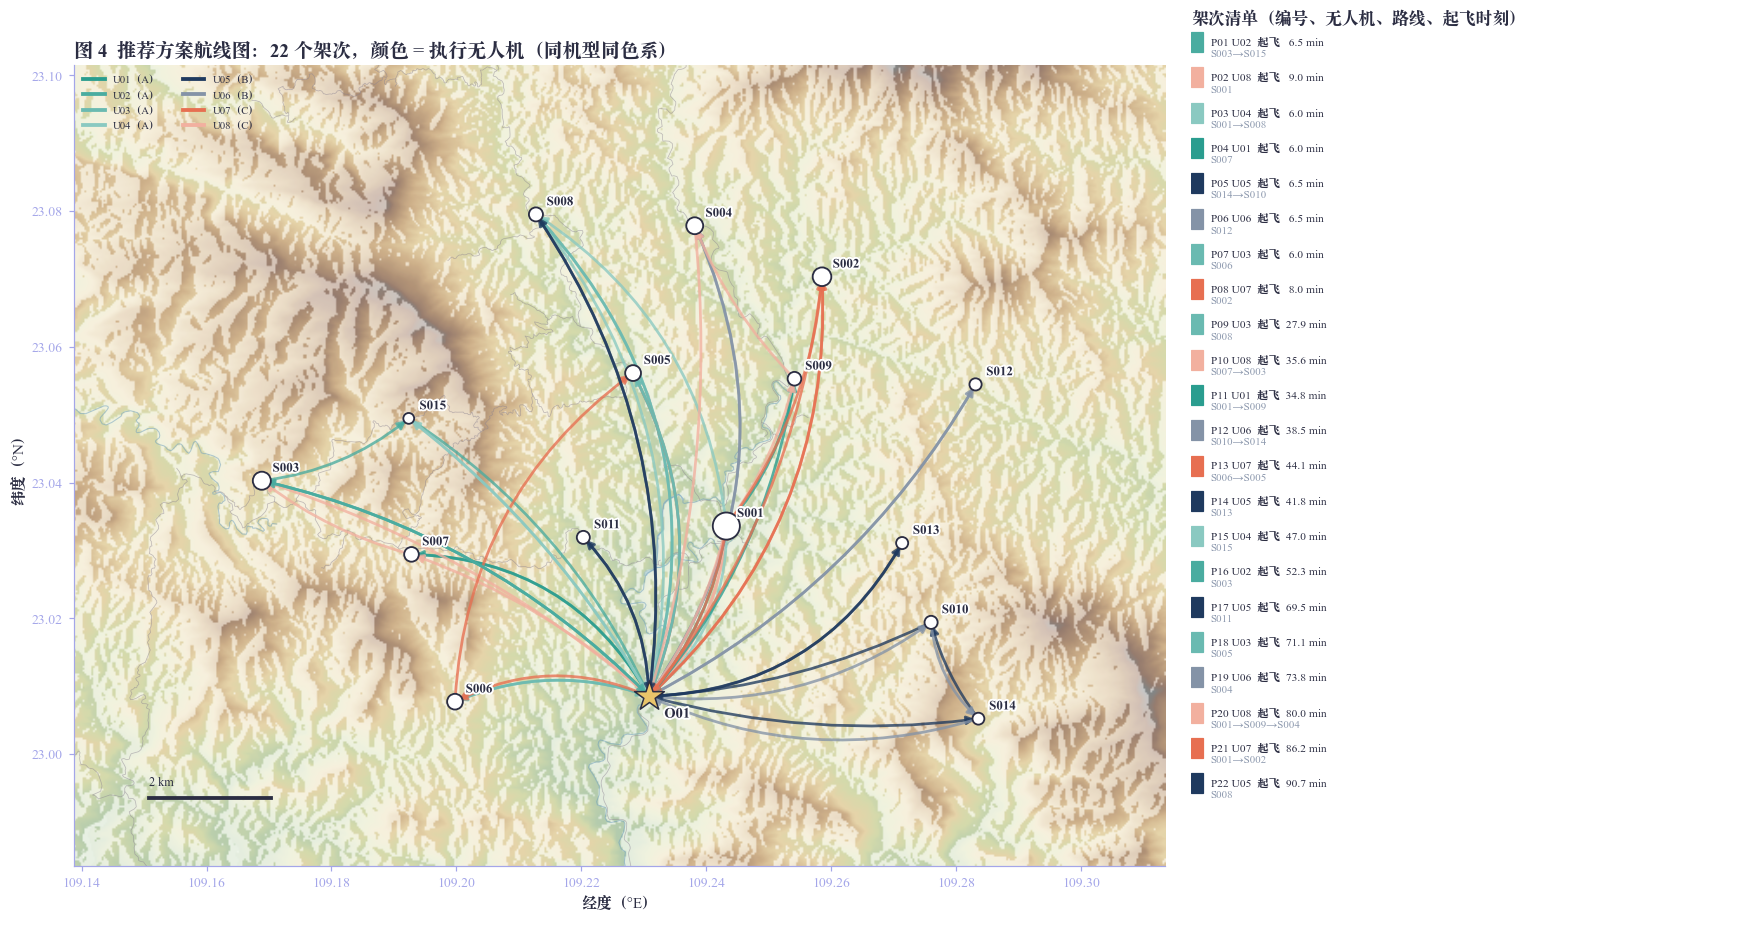

In [14]:
# 图 4：地形、真实服务区坐标、推荐方案路线与时序列表。
pad_lon,pad_lat=.030,.022
lon_min,lon_max=min(LONS)-pad_lon,max(LONS)+pad_lon
lat_min,lat_max=min(LATS)-pad_lat,max(LATS)+pad_lat
c0=max(0,int((lon_min-GEO['lon0'])/GEO['dx'])); c1=min(NCOL,int((lon_max-GEO['lon0'])/GEO['dx']))
r0=max(0,int((GEO['lat0']-lat_max)/GEO['dy'])); r1=min(NROW,int((GEO['lat0']-lat_min)/GEO['dy']))
sub=DEM[r0:r1,c0:c1]
extent=[GEO['lon0']+c0*GEO['dx'],GEO['lon0']+c1*GEO['dx'],
        GEO['lat0']-r1*GEO['dy'],GEO['lat0']-r0*GEO['dy']]
ASPECT=1/math.cos(math.radians((lat_min+lat_max)/2))
cmap_hypso=LinearSegmentedColormap.from_list('hypso',['#C9DCC6','#E3E7C5','#EFE3C3','#DFC9A9','#C7AE95','#B39B8E','#A1A5A6'])
rgb=LightSource(azdeg=315,altdeg=40).shade(np.nan_to_num(sub,nan=np.nanmin(sub)),cmap=cmap_hypso,
    blend_mode='soft',vert_exag=1.2,dx=GEO['dx'])
fig=plt.figure(figsize=(16,9.2)); ax=fig.add_axes([.04,.06,.62,.9]); ax.grid(False)
ax.imshow(rgb,extent=extent,aspect=ASPECT,interpolation='bilinear',zorder=0,alpha=.9)
polys=[grp[['经度','纬度']].to_numpy() for _,grp in water.groupby(['水体要素编号','多边形编号','环编号']) if len(grp)>=3]
ax.add_collection(PolyCollection(polys,facecolors='#8DB8D0',edgecolors='none',alpha=.42,zorder=1))
for df,id_col,color,lw in [(rivers,'水系要素编号','#6D9DBD',.7),(roads,'道路要素编号','#8A8190',.5)]:
    lines=[grp[['经度','纬度']].to_numpy() for _,grp in df.groupby(id_col) if len(grp)>1]
    ax.add_collection(LineCollection(lines,colors=color,linewidths=lw,alpha=.5,zorder=2))
for r in plan_df.itertuples(index=False):
    k=int(r.架次[1:]); col=UAV_COLOR[r.无人机]; rad=.10+.045*(k%5)
    nodes=[0]+[AREA_IDX[x] for x in r.路线.split('→')[1:-1]]+[0]
    for i,j in zip(nodes[:-1],nodes[1:]):
        ax.annotate('',xy=(LONS[j],LATS[j]),xytext=(LONS[i],LATS[i]),zorder=4,
                    arrowprops=dict(arrowstyle='-|>',mutation_scale=11,
                                    connectionstyle=f'arc3,rad={rad if i<j else -rad}',
                                    color=col,lw=1.8,alpha=.78))
sizes=40+6*np.sqrt(areas['pop'])
ax.scatter(areas.lon,areas.lat,s=sizes,facecolor='white',edgecolor=PAL['ink'],linewidths=1.2,zorder=6)
for r in areas.itertuples():
    ax.annotate(r.id,(r.lon,r.lat),xytext=(7,6),textcoords='offset points',fontsize=8.5,
                fontweight='bold',path_effects=HALO,zorder=8)
ax.scatter([LONS[0]],[LATS[0]],s=420,marker='*',color=PAL['gold'],edgecolor=PAL['ink'],linewidths=1,zorder=9)
ax.annotate('O01',(LONS[0],LATS[0]),xytext=(10,-14),textcoords='offset points',fontsize=9.5,
            fontweight='bold',path_effects=HALO,zorder=10)
m_per_deg_lon=dist_m(LONS[0],LATS[0],LONS[0]+.01,LATS[0])/.01
sb=2000/m_per_deg_lon
ax.plot([extent[0]+.012,extent[0]+.012+sb],[extent[2]+.01]*2,color=PAL['ink'],lw=2.5)
ax.text(extent[0]+.012,extent[2]+.012,'2 km',fontsize=8)
ax.set_xlim(extent[0],extent[1]); ax.set_ylim(extent[2],extent[3])
ax.set_xlabel('经度（°E）'); ax.set_ylabel('纬度（°N）')
ax.set_title(f'图 4  推荐方案航线图：{len(plan_df)} 个架次，颜色 = 执行无人机（同机型同色系）',loc='left',fontsize=12.5)
ax.legend(handles=[Line2D([],[],color=UAV_COLOR[u],lw=2.5,label=f'{u}（{UAV_TYPE[u]}）') for u in UAV_LIST],
          loc='upper left',ncol=2,fontsize=7)
ax2=fig.add_axes([.675,.06,.31,.9]); ax2.axis('off')
ax2.text(0,1.,'架次清单（编号、无人机、路线、起飞时刻）',fontsize=11,fontweight='bold',va='top')
for i,r in enumerate(plan_df.itertuples(index=False)):
    y=.965-i*(.93/max(24,len(plan_df)))
    ax2.add_patch(Rectangle((0,y-.011),.022,.022,color=UAV_COLOR[r.无人机],transform=ax2.transAxes))
    ax2.text(.035,y,f'{r.架次} {r.无人机}  起飞 {r.起飞时刻s/60:5.1f} min',
             fontsize=7.5,va='center')
    route=r.路线.replace('O01→','').replace('→O01','')
    ax2.text(.035,y-.0125,route,fontsize=7.2,va='center',color=PAL['grey'])
savefig(fig,'图04_推荐方案航线图'); plt.show()


## 15 图 5：调度甘特图（无人机 + 电池）

上半部分每行一架无人机，每个条带为一个架次，内部按“工位准备与装箱 / 飞行 / 服务区交接”三阶段着色，并标注架次与停靠服务区；竖线标出硬截止时刻。下半部分每行一组电池：实心段为任务占用并标注结束 SOC，浅色段为两阶段充电，斜线标识慢充。两部分共用时间轴，可直接查看无人机周转和电池充电是否成为瓶颈。


🖼️ 已保存 q2-main-8000-polish-4000-output/图05_调度甘特图.png


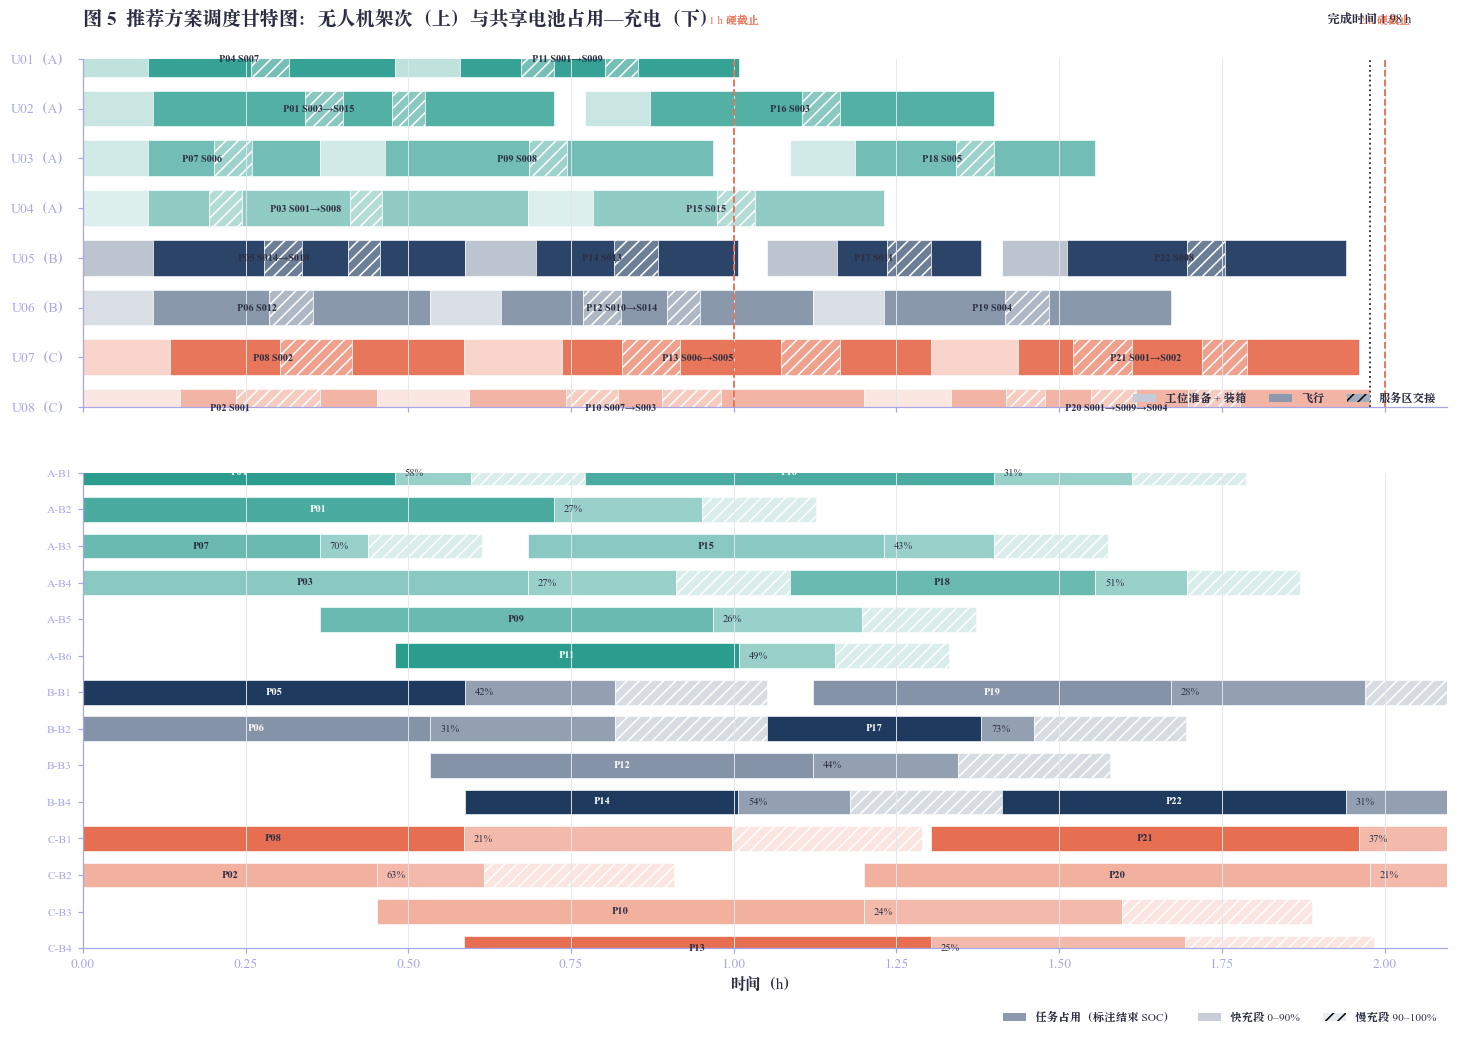

In [15]:
# 图 5：上半部分为无人机任务阶段，下半部分为电池任务和充电阶段。
mkh=PLAN_M['M']/3600
fig=plt.figure(figsize=(16,10.5))
gs=fig.add_gridspec(2,1,height_ratios=[len(UAV_LIST),len([bt for g in TYPES for bt in BATTS[g]])*.78],hspace=.16)
ax=fig.add_subplot(gs[0]); ax.grid(False,axis='y')
ypos={u:k for k,u in enumerate(UAV_LIST)}
for r in seg_df.itertuples(index=False):
    y=ypos[r.无人机]; col=UAV_COLOR[r.无人机]
    if r.阶段=='prep': fc,hatch,alpha=shade(col,.70),'',1.
    elif r.阶段=='fly': fc,hatch,alpha=col,'',.95
    else: fc,hatch,alpha=shade(col,.35),'///',1.
    ax.add_patch(Rectangle((r.开始s/3600,y-.36),(r.结束s-r.开始s)/3600,.72,
                           facecolor=fc,edgecolor='white',lw=.4,hatch=hatch,alpha=alpha))
for r in plan_df.itertuples(index=False):
    y=ypos[r.无人机]
    route=r.路线.replace('O01→','').replace('→O01','')
    ax.text((r.开始时刻s+r.结束时刻s)/7200,y+.02,f'{r.架次} {route}',ha='center',va='center',
            fontsize=6.7,color=PAL['ink'],fontweight='bold')
for h,lab in [(1,'1 h 硬截止'),(2,'2 h 硬截止'),(3,'3 h 硬截止')]:
    if h<mkh*1.06:
        ax.axvline(h,color=PAL['coral'],lw=1.2,ls='--',zorder=2)
        ax.text(h,-.66,lab,color=PAL['coral'],fontsize=7.3,ha='center',va='bottom')
ax.axvline(mkh,color=PAL['ink'],lw=1.2,ls=':',zorder=2)
ax.text(mkh,-.66,f'完成时间 {mkh:.2f} h',color=PAL['ink'],fontsize=8.2,ha='center',va='bottom')
ax.set_yticks(range(len(UAV_LIST))); ax.set_yticklabels([f'{u}（{UAV_TYPE[u]}）' for u in UAV_LIST])
ax.invert_yaxis(); ax.set_xlim(0,mkh*1.06); ax.tick_params(axis='x',labelbottom=False)
ax.legend(handles=[Rectangle((0,0),1,1,facecolor=shade(PAL['grey'],.5),label='工位准备 + 装箱'),
                   Rectangle((0,0),1,1,facecolor=PAL['grey'],label='飞行'),
                   Rectangle((0,0),1,1,facecolor=shade(PAL['grey'],.2),hatch='///',label='服务区交接')],
          loc='lower right',bbox_to_anchor=(1,-.02),ncol=3,fontsize=7.5)
ax.set_title('图 5  推荐方案调度甘特图：无人机架次（上）与共享电池占用—充电（下）',loc='left',fontsize=12.5,pad=22)
ax=fig.add_subplot(gs[1],sharex=fig.axes[0]); ax.grid(False,axis='y')
bat_list=[bt for g in TYPES for bt in BATTS[g]]; bpos={bt:k for k,bt in enumerate(bat_list)}
for r in bat_df.itertuples(index=False):
    y=bpos[r.电池]; col=UAV_COLOR[r.无人机]
    ax.add_patch(Rectangle((r.使用开始s/3600,y-.34),(r.使用结束s-r.使用开始s)/3600,.68,
                           facecolor=col,edgecolor='white',lw=.4))
    if r.快充结束s>r.充电开始s:
        ax.add_patch(Rectangle((r.充电开始s/3600,y-.34),(r.快充结束s-r.充电开始s)/3600,.68,
                               facecolor=shade(TYPE_COLOR[r.机型],.52),edgecolor='white',lw=.4))
    if r.充电结束s>r.快充结束s:
        ax.add_patch(Rectangle((r.快充结束s/3600,y-.34),(r.充电结束s-r.快充结束s)/3600,.68,
                               facecolor=shade(TYPE_COLOR[r.机型],.82),edgecolor='white',lw=.4,hatch='///'))
    ax.text(r.使用结束s/3600+.015,y,f'{r.结束SOC*100:.0f}%',fontsize=6.8,va='center',ha='left',color=PAL['ink'])
    ax.text((r.使用开始s+r.使用结束s)/7200,y,r.架次,fontsize=6.8,va='center',ha='center',
            color='white' if mpl.colors.rgb_to_hsv(UAV_COLOR[r.无人机])[2]<.72 else PAL['ink'],fontweight='bold')
ax.set_yticks(range(len(bat_list))); ax.set_yticklabels(bat_list,fontsize=7.5); ax.invert_yaxis()
ax.set_xlabel('时间（h）'); ax.set_xlim(0,mkh*1.06)
ax.legend(handles=[Rectangle((0,0),1,1,facecolor=PAL['grey'],label='任务占用（标注结束 SOC）'),
                   Rectangle((0,0),1,1,facecolor=shade(PAL['grey'],.52),label='快充段 0–90%'),
                   Rectangle((0,0),1,1,facecolor=shade(PAL['grey'],.82),hatch='///',label='慢充段 90–100%')],
          loc='lower right',bbox_to_anchor=(1,-.18),ncol=3,fontsize=7.5)
fig.tight_layout(); savefig(fig,'图05_调度甘特图'); plt.show()


## 16 图 6、图 7：逐箱送达时刻与电池 SOC 轨迹

图 6 中每个货箱对应一个送达时刻点，并以短线连接期望送达时间：提前为青绿色，迟到为珊瑚色，硬时限以红色三角标出。图 7 展示各共享电池的任务放电、两阶段充电和待命过程；20% 返航电量下限与 90% 快慢充分界以虚线标出。


🖼️ 已保存 q2-main-8000-polish-4000-output/图06_逐箱送达时刻.png


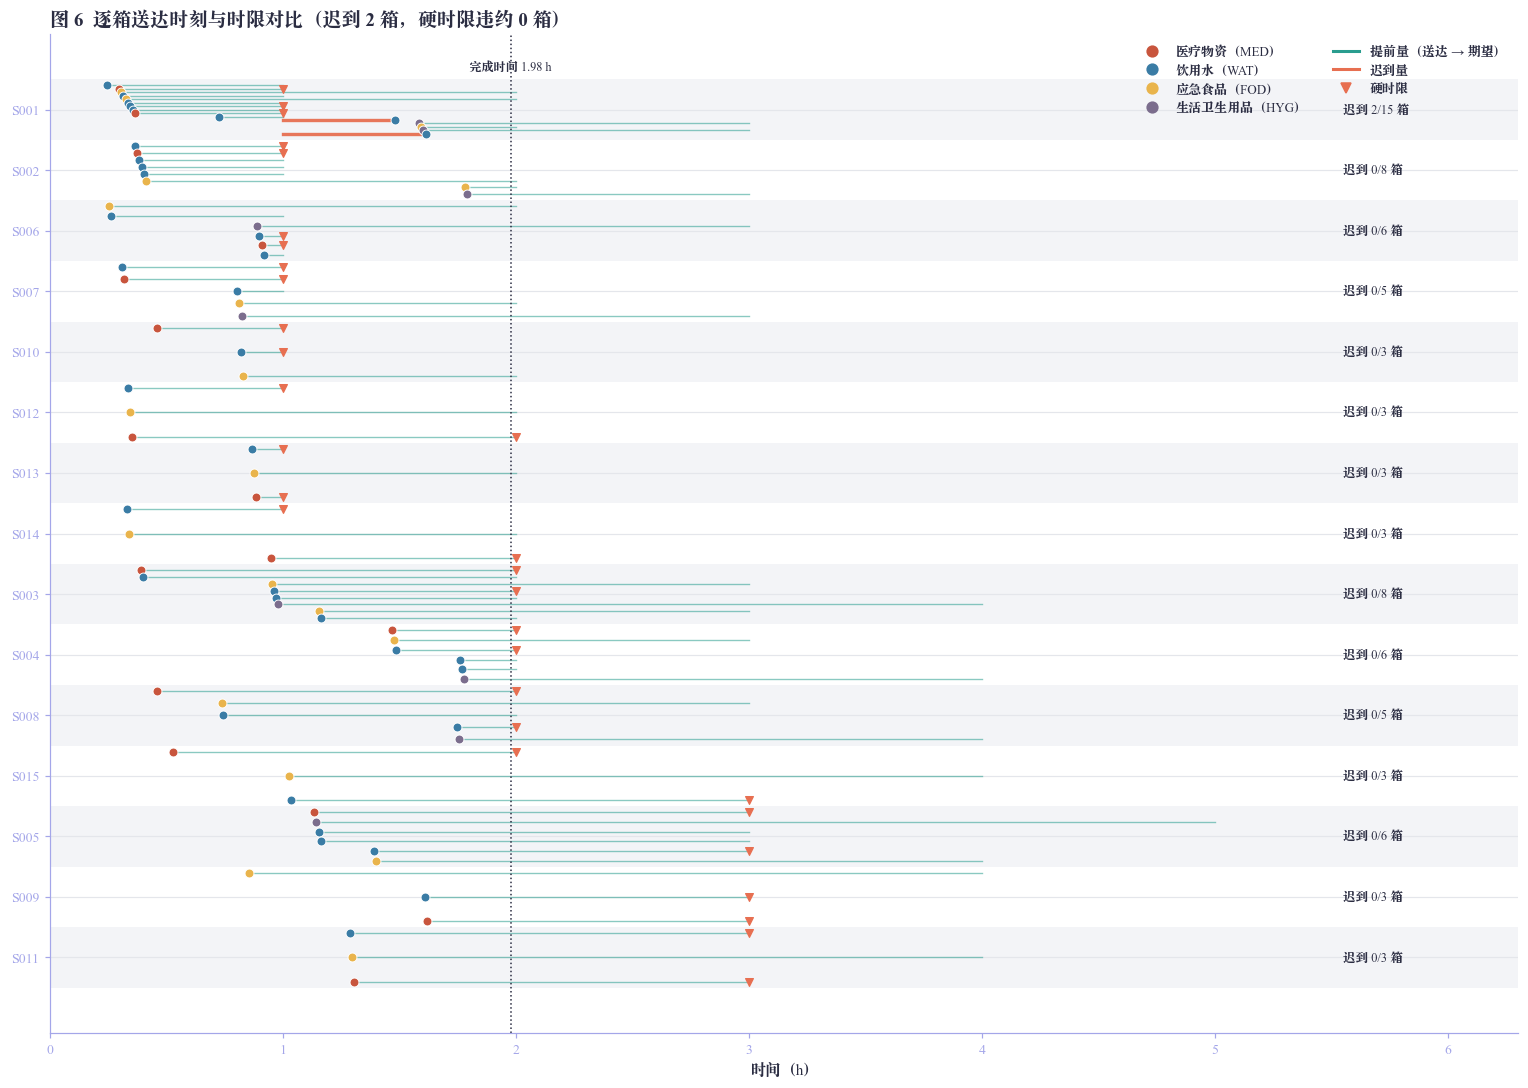

In [16]:
# 图 6：逐箱送达时刻与期望时刻、硬时限的逐箱对照。
fig,ax=plt.subplots(figsize=(14,10))
for yi,a in enumerate(areas_sorted):
    sub=box_df[box_df['服务区']==a].sort_values('送达时刻s').reset_index(drop=True)
    if yi%2==0: ax.axhspan(yi-.5,yi+.5,color='#F3F4F7',lw=0,zorder=0)
    ax.axhline(yi,color=PAL['mist'],lw=.8,zorder=1)
    n=len(sub)
    for j,r in sub.iterrows():
        y=yi+(j-(n-1)/2)*(.8/max(n-1,1)) if n>1 else yi
        t=r['送达时刻s']/3600; te=r['期望时刻s']/3600
        col=PAL['teal'] if t<=te else PAL['coral']
        ax.plot([t,te],[y,y],color=col,lw=.9 if t<=te else 2.2,alpha=.55 if t<=te else .95,zorder=2)
        ax.scatter(t,y,s=34,color=MAT_COLOR[r['物资类型']],edgecolor='white',lw=.6,zorder=4)
        if np.isfinite(r['硬时限s']):
            ax.scatter(r['硬时限s']/3600,y,marker='v',s=26,color=PAL['coral'],zorder=5)
    late=int(sub['是否迟到'].sum())
    ax.text(5.55,yi,f'迟到 {late}/{len(sub)} 箱',va='center',fontsize=8.2,color=PAL['ink'])
ax.axvline(PLAN_M['M']/3600,color=PAL['ink'],lw=1,ls=':')
ax.text(PLAN_M['M']/3600,-.65,f'完成时间 {PLAN_M["M"]/3600:.2f} h',fontsize=8,color=PAL['ink'],ha='center')
ax.set_yticks(range(len(areas_sorted))); ax.set_yticklabels(areas_sorted); ax.invert_yaxis(); ax.grid(False)
ax.set_xlim(0,6.3); ax.set_xlabel('时间（h）')
handles=[Line2D([],[],marker='o',ls='none',color=MAT_COLOR[m],markersize=7,label=f'{m}（{MAT_ABBR[m]}）') for m in MAT_ORDER]
handles += [Line2D([],[],color=PAL['teal'],lw=2,label='提前量（送达 → 期望）'),
            Line2D([],[],color=PAL['coral'],lw=2,label='迟到量'),
            Line2D([],[],marker='v',ls='none',color=PAL['coral'],markersize=7,label='硬时限')]
ax.legend(handles=handles,loc='upper right',ncol=2,fontsize=8.5)
late_n=int(box_df['是否迟到'].sum())
hard_n=int((box_df['硬时限s'].notna()&box_df['硬时限余量s'].lt(-1e-7)).sum())
ax.set_title(f'图 6  逐箱送达时刻与时限对比（迟到 {late_n} 箱，硬时限违约 {hard_n} 箱）',loc='left',fontsize=12.5)
fig.tight_layout(); savefig(fig,'图06_逐箱送达时刻'); plt.show()


🖼️ 已保存 q2-main-8000-polish-4000-output/图07_电池SOC轨迹.png


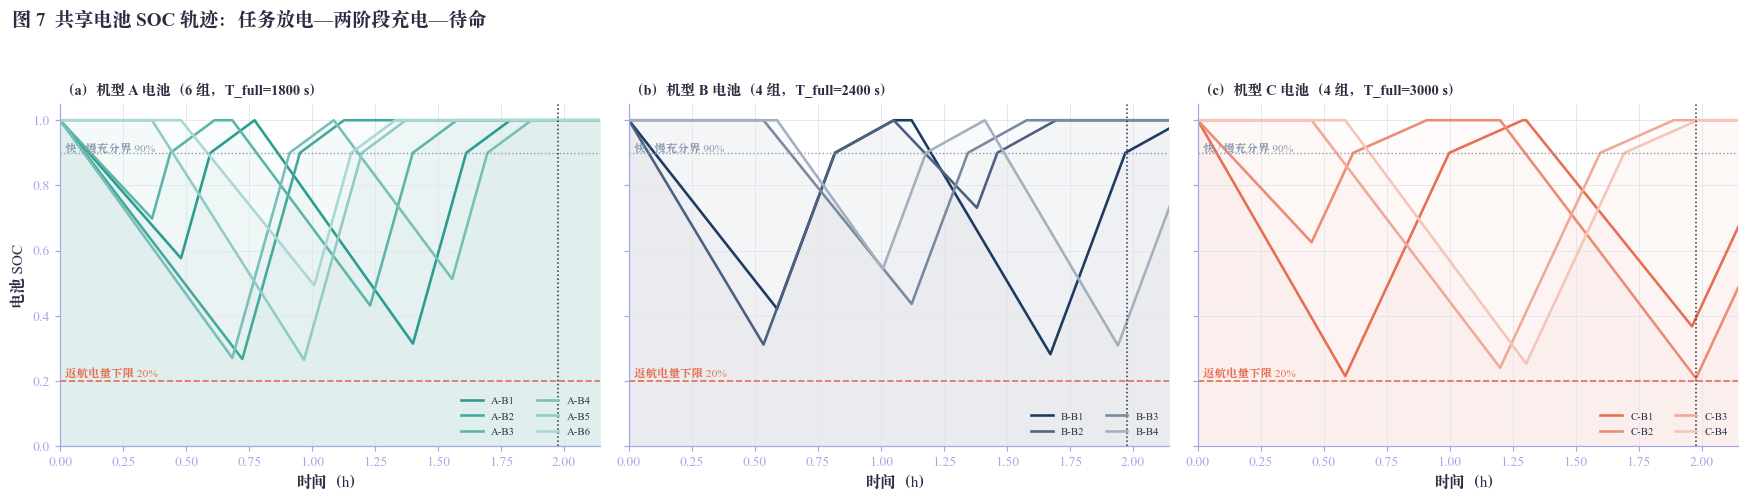

In [17]:
def soc_trajectory(bt,t_end):
    g=next(g for g in TYPES if bt in BATTS[g])
    uses=bat_df[bat_df['电池']==bt].sort_values('使用开始s')
    xs=[0.]; ys=[1.]
    for r in uses.itertuples(index=False):
        if r.使用开始s>xs[-1]:
            xs.append(r.使用开始s); ys.append(1.)
        xs.extend([r.使用开始s,r.使用结束s]); ys.extend([1.,r.结束SOC])
        if r.结束SOC<.9:
            xs.append(r.快充结束s); ys.append(.9)
        xs.append(r.充电结束s); ys.append(1.)
    if t_end>xs[-1]: xs.append(t_end); ys.append(1.)
    return np.asarray(xs)/3600,np.asarray(ys)

fig,axes=plt.subplots(1,3,figsize=(16,4.6),sharey=True)
for ax,g in zip(axes,TYPES):
    bl=BATTS[g]
    for k,bt in enumerate(bl):
        xs,ys=soc_trajectory(bt,PLAN_M['M']+600)
        col=shade(TYPE_COLOR[g],.6*k/max(1,len(bl)-1))
        ax.plot(xs,ys,color=col,lw=1.7,label=bt)
        ax.fill_between(xs,0,ys,color=TYPE_COLOR[g],alpha=.025,lw=0)
    ax.axhline(P[g].rho,color=PAL['coral'],lw=1.1,ls='--')
    ax.axhline(.9,color=PAL['grey'],lw=.9,ls=':')
    ax.axvline(PLAN_M['M']/3600,color=PAL['ink'],lw=1,ls=':')
    ax.text(.02,P[g].rho+.015,'返航电量下限 20%',fontsize=7.5,color=PAL['coral'])
    ax.text(.02,.905,'快 / 慢充分界 90%',fontsize=7.5,color=PAL['grey'])
    ax.set_title(f'（{chr(97+TYPES.index(g))}）机型 {g} 电池（{BATT[g][0]} 组，T_full={BATT[g][1]:.0f} s）',loc='left',fontsize=9.5)
    ax.set_xlabel('时间（h）'); ax.set_ylim(0,1.05); ax.set_xlim(0,(PLAN_M['M']+600)/3600)
    ax.legend(loc='lower right',ncol=2,fontsize=7)
axes[0].set_ylabel('电池 SOC')
fig.suptitle('图 7  共享电池 SOC 轨迹：任务放电—两阶段充电—待命',x=.01,ha='left',fontsize=12.5,fontweight='bold')
fig.tight_layout(rect=[0,0,1,.94]); savefig(fig,'图07_电池SOC轨迹'); plt.show()


## 17 图 8：四指标权衡

图 8（a）用平行坐标比较推荐方案与四种权重情景，各轴按 min–max 归一化并标注实际值。图 8（b）把 ALNS 搜索过程中接受的可行解绘成解云：横轴为完成时间，纵轴为总能耗，颜色表示及时性、点面积表示架次数，深色描边为四维非支配解，星形为五个候选方案。


🖼️ 已保存 q2-main-8000-polish-4000-output/图08_指标权衡.png


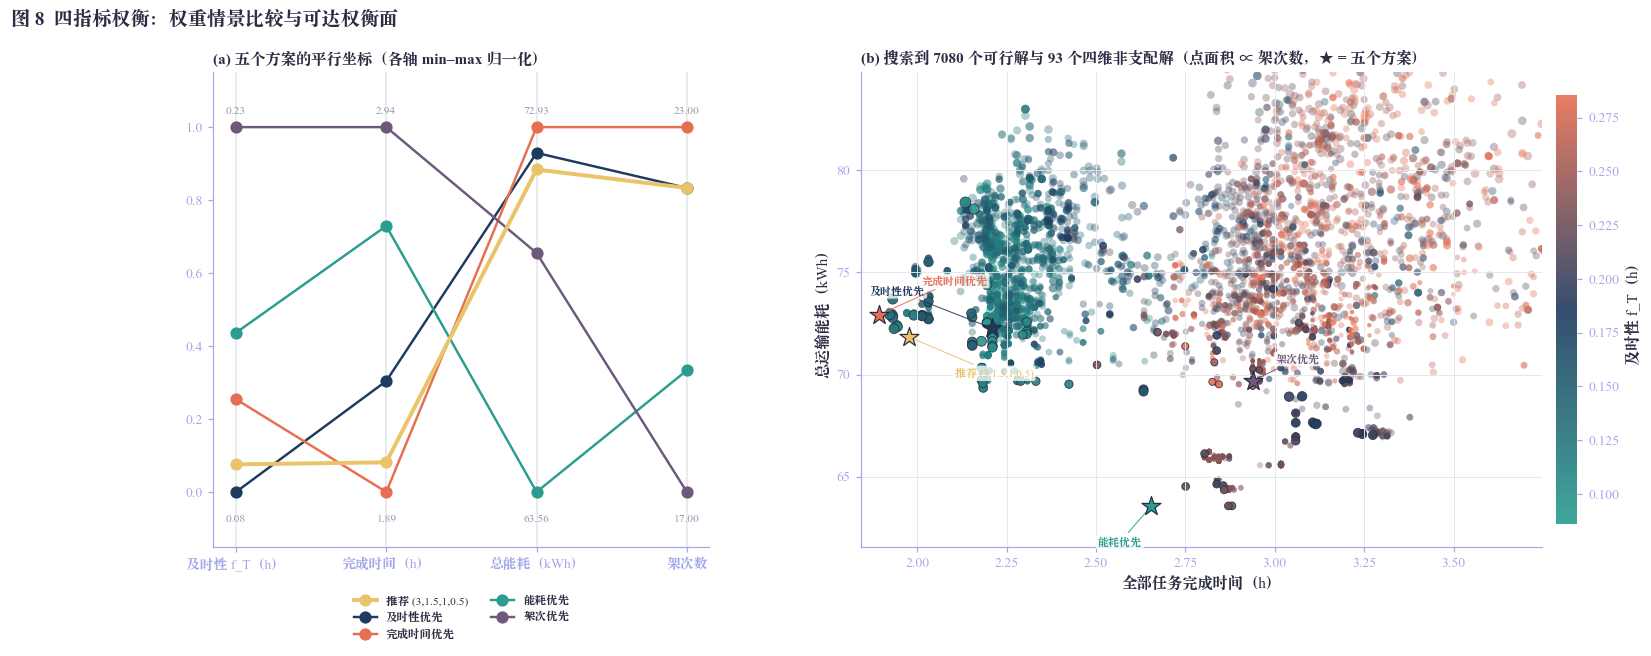

In [18]:
# 图 8：权重情景的平行坐标与搜索可达权衡面。
fig=plt.figure(figsize=(16,5.6))
gs=fig.add_gridspec(1,2,width_ratios=[.9,1.3],wspace=.25)
ax=fig.add_subplot(gs[0]); ax.grid(False)
mets=['及时性fT','完成时间h','总能耗kWh','架次数']
M=scen_df[mets].astype(float).to_numpy()
lo,hi=M.min(axis=0),M.max(axis=0)
Mn=(M-lo)/np.where(hi-lo>0,hi-lo,1.)
colors=[PAL['gold'],PAL['indigo'],PAL['coral'],PAL['teal'],PAL['plum']]
for k,(name,row) in enumerate(zip(scen_df.index,Mn)):
    ax.plot(range(4),row,marker='o',ms=7,lw=2.6 if k==0 else 1.6,
            color=colors[k],label=name,zorder=5 if k==0 else 3)
for j in range(4):
    ax.axvline(j,color=PAL['mist'],lw=1,zorder=1)
    ax.text(j,-.06,f'{lo[j]:.2f}',ha='center',va='top',fontsize=7.5,color=PAL['grey'])
    ax.text(j,1.03,f'{hi[j]:.2f}',ha='center',va='bottom',fontsize=7.5,color=PAL['grey'])
ax.set_xticks(range(4)); ax.set_xticklabels(['及时性 f_T（h）','完成时间（h）','总能耗（kWh）','架次数'])
ax.set_ylim(-.15,1.15)
ax.legend(loc='upper center',bbox_to_anchor=(.5,-.08),ncol=2,fontsize=7.5)
ax.set_title('(a) 五个方案的平行坐标（各轴 min–max 归一化）',loc='left',fontsize=10)
ax=fig.add_subplot(gs[1])
fT_all=pts[:,0]
norm_T=Normalize(vmin=float(fT_all.min()),vmax=float(np.percentile(fT_all,95)))
sizes=8+3*(pts[:,3]-pts[:,3].min())
ax.scatter(pts[~nd,1],pts[~nd,2],c=fT_all[~nd],cmap=CMAP_SEQ,norm=norm_T,
           s=sizes[~nd],alpha=.35,lw=0)
sc=ax.scatter(pts[nd,1],pts[nd,2],c=fT_all[nd],cmap=CMAP_SEQ,norm=norm_T,
              s=18+4*(pts[nd,3]-pts[:,3].min()),edgecolor=PAL['ink'],lw=.55,alpha=.9)
groups=[]
for k,(name,row) in enumerate(scen_df.iterrows()):
    x=float(row['完成时间h']); y=float(row['总能耗kWh'])
    match=next((g for g in groups if abs(g['x']-x)<1e-6 and abs(g['y']-y)<1e-6),None)
    label=name.split('（')[0]
    if match is None:
        groups.append(dict(x=x,y=y,k=k,labels=[label]))
    else:
        match['labels'].append(label)
offsets=[(30,-26),(-80,22),(28,20),(-35,-26),(15,12)]
for j,g in enumerate(groups):
    k=g['k']; x=g['x']; y=g['y']
    label=' / '.join(g['labels'])
    ax.scatter(x,y,s=170,marker='*',color=colors[k],edgecolor=PAL['ink'],lw=.8,zorder=6)
    ax.annotate(label,(x,y),xytext=offsets[min(j,len(offsets)-1)],textcoords='offset points',
                fontsize=7.2,color=colors[k],ha='left',
                bbox=dict(boxstyle='round,pad=.18',fc='white',ec='none',alpha=.78),
                arrowprops=dict(arrowstyle='-',color=colors[k],lw=.6))
ax.set_xlim(pts[:,1].min()-.08,np.percentile(pts[:,1],99))
ax.set_ylim(pts[:,2].min()-2,np.percentile(pts[:,2],99))
cb=fig.colorbar(sc,ax=ax,fraction=.03,pad=.02); cb.set_label('及时性 f_T（h）'); cb.outline.set_visible(False)
ax.set_xlabel('全部任务完成时间（h）'); ax.set_ylabel('总运输能耗（kWh）')
ax.set_title(f'(b) 搜索到 {len(pts)} 个可行解与 {int(nd.sum())} 个四维非支配解（点面积 ∝ 架次数，★ = 五个方案）',loc='left',fontsize=10)
fig.suptitle('图 8  四指标权衡：权重情景比较与可达权衡面',x=.01,ha='left',fontsize=12.5,fontweight='bold')
fig.tight_layout(rect=[0,0,1,.94]); savefig(fig,'图08_指标权衡'); plt.show()


## 18 资源可行性检验与图 9

不依赖解码器内部的可行标记，从结果表独立复核 8 条规则：每箱恰好装运一次；每架次质量、体积和能量可行；无人机架次不重叠；电池任务占用和充满时间不重叠；任务结束 SOC 不低于返航电量下限；医疗物资与首批箱满足硬时限；每型电池使用数不超过库存；架次开始时刻非负且路线从 O01 出发并返回。图 9 展示无人机任务占用、电池占用与充电，以及任意时刻在飞无人机数和充电池数。


,检验项,通过,说明
0,① 每箱恰好装运一次,True,80 箱，80 个不同编号
1,② 载质量/体积/能量约束,True,最紧约束利用率 99.0%
2,③ 无人机架次不重叠,True,相邻架次最小间隔 0 s
3,④ 电池占用—充满—再占用不重叠,True,充电结束到再次使用最小间隔 0 s
4,⑤ 任务结束 SOC ≥ 返航电量下限,True,最低 SOC 20.8%
5,⑥ 医疗物资与首批箱硬时限,True,31 箱，最小提前量 5.5 min
6,⑦ 电池使用数 ≤ 库存,True,"A: 6/6, B: 4/4, C: 4/4"
7,⑧ 从 O01 出发并返回，开始时刻 ≥ 0,True,


资源可行性检验：全部通过 ✓


🖼️ 已保存 q2-main-8000-polish-4000-output/图09_资源可行性画像.png


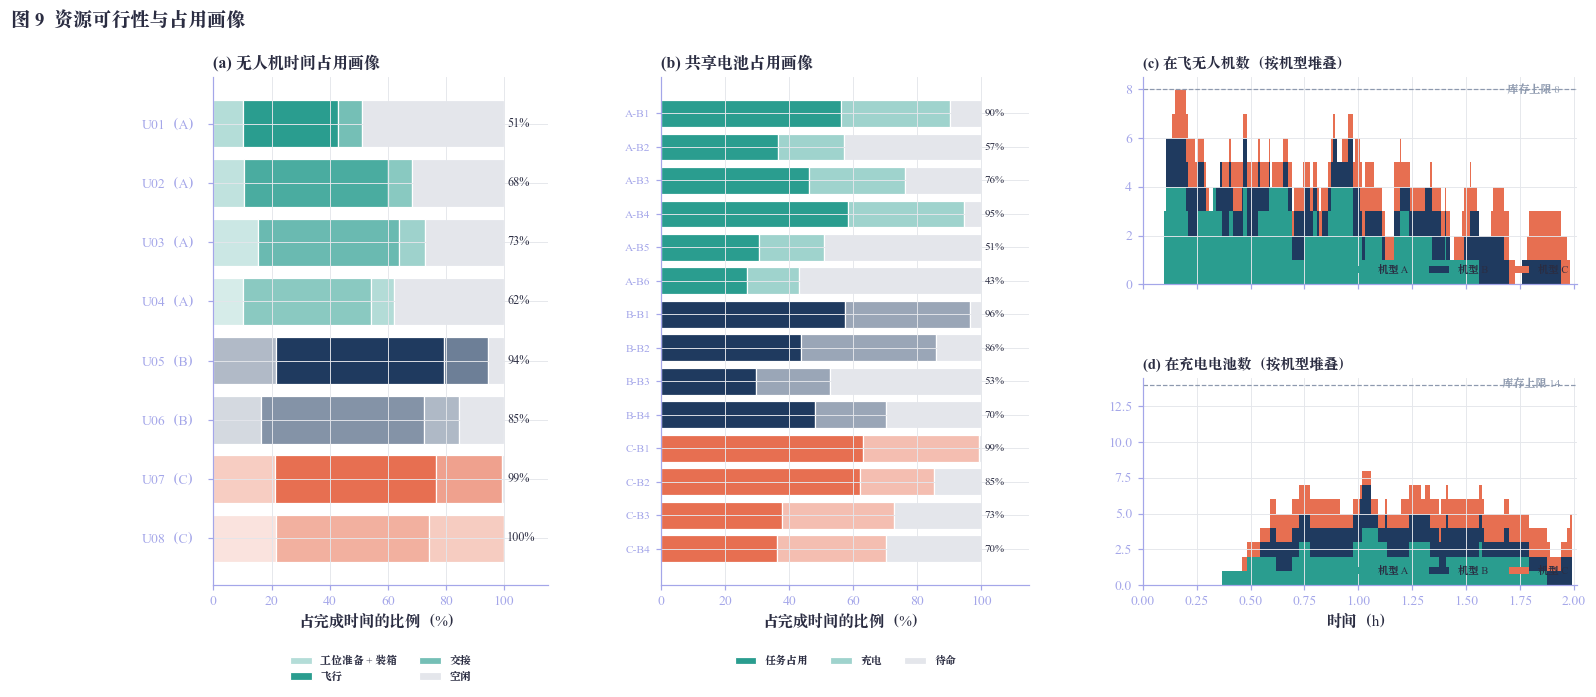

In [19]:
def verify(plan_df,box_df,bat_df,sorties,m):
    res=[]
    ids=box_df['货箱编号'].tolist()
    ok=(len(ids)==len(BOX_IDS) and len(set(ids))==len(BOX_IDS) and set(ids)==set(BOX_IDS))
    res.append(('① 每箱恰好装运一次',ok,f'{len(ids)} 箱，{len(set(ids))} 个不同编号'))
    ok=True; worst=0.
    for s in sorties:
        ev=evaluate(s)
        ok &= ev is not None
        if ev is not None:
            worst=max(worst,ev['E']/BUDGET[s.g],ev['mass']/P[s.g].Q,ev['vol']/P[s.g].V)
    res.append(('② 载质量/体积/能量约束',ok,f'最紧约束利用率 {worst*100:.1f}%'))
    ok=True; gap=math.inf
    for u in UAV_LIST:
        d=plan_df[plan_df['无人机']==u].sort_values('开始时刻s')
        for a,b in zip(d['结束时刻s'].to_numpy()[:-1],d['开始时刻s'].to_numpy()[1:]):
            ok &= b>=a-1e-6; gap=min(gap,b-a)
    res.append(('③ 无人机架次不重叠',ok,f'相邻架次最小间隔 {gap:.0f} s' if gap<math.inf else '无相邻架次'))
    ok=True; bgap=math.inf
    for bt in [bt for g in TYPES for bt in BATTS[g]]:
        d=bat_df[bat_df['电池']==bt].sort_values('使用开始s')
        for a,b in zip(d['充电结束s'].to_numpy()[:-1],d['使用开始s'].to_numpy()[1:]):
            ok &= b>=a-1e-6; bgap=min(bgap,b-a)
    res.append(('④ 电池占用—充满—再占用不重叠',ok,
                f'充电结束到再次使用最小间隔 {bgap:.0f} s' if bgap<math.inf else '每组电池至多用一次'))
    min_soc=float(plan_df['返航SOC'].min())
    ok=all(plan_df['返航SOC'].to_numpy()>=plan_df['机型'].map(lambda g:P[g].rho).to_numpy()-1e-9)
    res.append(('⑤ 任务结束 SOC ≥ 返航电量下限',ok,f'最低 SOC {min_soc*100:.1f}%'))
    hb=box_df[box_df['硬时限s'].notna()]
    ok=bool((hb['送达时刻s']<=hb['硬时限s']+1e-6).all())
    slack=float((hb['硬时限s']-hb['送达时刻s']).min()) if len(hb) else math.nan
    res.append(('⑥ 医疗物资与首批箱硬时限',ok,f'{len(hb)} 箱，最小提前量 {slack/60:.1f} min'))
    used=Counter(plan_df['电池'])
    counts={g:sum(1 for bt in BATTS[g] if bt in used) for g in TYPES}
    ok=all(counts[g]<=BATT[g][0] for g in TYPES)
    res.append(('⑦ 电池使用数 ≤ 库存',ok,', '.join(f'{g}: {counts[g]}/{BATT[g][0]}' for g in TYPES)))
    ok=bool((plan_df['开始时刻s']>=-1e-9).all() and plan_df['路线'].str.startswith('O01').all()
            and plan_df['路线'].str.endswith('O01').all())
    res.append(('⑧ 从 O01 出发并返回，开始时刻 ≥ 0',ok,''))
    return pd.DataFrame(res,columns=['检验项','通过','说明'])

VER=verify(plan_df,box_df,bat_df,PLAN_SORTIES,PLAN_M)
display(VER)
print('资源可行性检验：'+('全部通过 ✓' if VER['通过'].all() else '存在未通过项 ✗'))

# 图 9：无人机时间占用、电池周转以及瞬时在飞/充电资源数量。
mk=PLAN_M['M']
fig=plt.figure(figsize=(16,6.))
gs=fig.add_gridspec(1,3,width_ratios=[1,1.1,1.3],wspace=.30)
ax=fig.add_subplot(gs[0])
comp={u:{'prep':0.,'fly':0.,'hand':0.} for u in UAV_LIST}
for r in seg_df.itertuples(index=False):
    comp[r.无人机][r.阶段]+=r.结束s-r.开始s
y=np.arange(len(UAV_LIST)); left=np.zeros(len(UAV_LIST))
for kind,label,light in [('prep','工位准备 + 装箱',.65),('fly','飞行',0.),('hand','交接',.35)]:
    vals=np.array([comp[u][kind] for u in UAV_LIST])/mk*100
    ax.barh(y,vals,left=left,color=[shade(UAV_COLOR[u],light) for u in UAV_LIST],
            edgecolor='white',label=label)
    left+=vals
ax.barh(y,100-left,left=left,color=PAL['mist'],edgecolor='white',label='空闲')
for yi in range(len(UAV_LIST)): ax.text(101,yi,f'{left[yi]:.0f}%',va='center',fontsize=8)
ax.set_yticks(y); ax.set_yticklabels([f'{u}（{UAV_TYPE[u]}）' for u in UAV_LIST])
ax.invert_yaxis(); ax.set_xlim(0,115); ax.set_xlabel('占完成时间的比例（%）')
ax.legend(loc='upper center',bbox_to_anchor=(.5,-.12),ncol=2,fontsize=7.1)
ax.set_title('(a) 无人机时间占用画像',loc='left',fontsize=10.5)
ax=fig.add_subplot(gs[1])
bat_list=[bt for g in TYPES for bt in BATTS[g]]
used=np.zeros(len(bat_list)); charged=np.zeros(len(bat_list))
for r in bat_df.itertuples(index=False):
    k=bat_list.index(r.电池)
    used[k]+=(r.使用结束s-r.使用开始s)/mk*100
    charged[k]+=(min(r.充电结束s,mk)-r.充电开始s)/mk*100
ax.barh(np.arange(len(bat_list)),used,color=[TYPE_COLOR[next(g for g in TYPES if bt in BATTS[g])] for bt in bat_list],
        edgecolor='white',label='任务占用')
ax.barh(np.arange(len(bat_list)),charged,left=used,
        color=[shade(TYPE_COLOR[next(g for g in TYPES if bt in BATTS[g])],.55) for bt in bat_list],
        edgecolor='white',label='充电')
ax.barh(np.arange(len(bat_list)),100-used-charged,left=used+charged,color=PAL['mist'],edgecolor='white',label='待命')
for yi,val in enumerate(used+charged): ax.text(101,yi,f'{val:.0f}%',va='center',fontsize=7.2)
ax.set_yticks(np.arange(len(bat_list))); ax.set_yticklabels(bat_list,fontsize=7.5)
ax.invert_yaxis(); ax.set_xlim(0,115); ax.set_xlabel('占完成时间的比例（%）')
ax.legend(loc='upper center',bbox_to_anchor=(.5,-.12),ncol=3,fontsize=7.1)
ax.set_title('(b) 共享电池占用画像',loc='left',fontsize=10.5)
gsub=gs[2].subgridspec(2,1,hspace=.45)
tgrid=np.arange(0,mk+60,30.)
fly={g:np.zeros(len(tgrid)) for g in TYPES}; charging={g:np.zeros(len(tgrid)) for g in TYPES}
for r in seg_df[seg_df['阶段']=='fly'].itertuples(index=False):
    fly[r.机型]+=(tgrid>=r.开始s)&(tgrid<r.结束s)
for r in bat_df.itertuples(index=False):
    charging[r.机型]+=(tgrid>=r.充电开始s)&(tgrid<r.充电结束s)
for row,(data,title,capacity) in enumerate([
    (fly,'(c) 在飞无人机数（按机型堆叠）',len(UAV_LIST)),
    (charging,'(d) 在充电电池数（按机型堆叠）',len(bat_list))]):
    ax=fig.add_subplot(gsub[row])
    ax.stackplot(tgrid/3600,[data[g] for g in TYPES],step='post',
                 colors=[TYPE_COLOR[g] for g in TYPES],labels=[f'机型 {g}' for g in TYPES])
    ax.axhline(capacity,color=PAL['grey'],lw=.8,ls='--')
    ax.text(mk/3600*.98,capacity-.15,f'库存上限 {capacity}',fontsize=7.3,color=PAL['grey'],ha='right')
    ax.set_xlim(0,mk/3600*1.02); ax.set_ylim(0,capacity+.5); ax.set_title(title,loc='left',fontsize=9.5)
    ax.legend(loc='lower right',ncol=3,fontsize=6.8)
    if row==1: ax.set_xlabel('时间（h）')
    else: ax.tick_params(labelbottom=False)
fig.suptitle('图 9  资源可行性与占用画像',x=.01,ha='left',fontsize=12.5,fontweight='bold')
fig.tight_layout(rect=[0,0,1,.94]); savefig(fig,'图09_资源可行性画像'); plt.show()
